# DATA IMPORT

In [ ]:
import pandas as pd
import numpy as np
import warnings
import gdown
import re
import os
from pathlib import Path

warnings.filterwarnings('ignore')

# 1. Thông tin URL
folder_url = "https://drive.google.com/drive/folders/1WMeIajroEakGEvWeIl75HM6DxTc1GJDv?usp=drive_link"
base_dir = Path("/content/temp_data")
base_dir.mkdir(parents=True, exist_ok=True)

# 2. Tải dữ liệu
match = re.search(r'folders/([\w-]+)', folder_url)
if match:
    folder_id = match.group(1)
    gdown.download_folder(id=folder_id, output=str(base_dir), quiet=True, use_cookies=False)

    subfolders = [f.path for f in os.scandir(base_dir) if f.is_dir()]
    if subfolders:
        DATA_DIR = subfolders[0] + '/'
    else:
        DATA_DIR = str(base_dir) + '/'
else:
    print("URL không ổn rồi!")

# 3. Đọc dữ liệu
orders      = pd.read_csv(DATA_DIR + 'orders.csv',      parse_dates=['order_date'])
products    = pd.read_csv(DATA_DIR + 'products.csv')
returns     = pd.read_csv(DATA_DIR + 'returns.csv',     parse_dates=['return_date'])
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv', parse_dates=['date'])
order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
customers   = pd.read_csv(DATA_DIR + 'customers.csv',   parse_dates=['signup_date'])
payments    = pd.read_csv(DATA_DIR + 'payments.csv')
geography   = pd.read_csv(DATA_DIR + 'geography.csv')
sales       = pd.read_csv(DATA_DIR + 'sales.csv',       parse_dates=['Date'])
inventory   = pd.read_csv(DATA_DIR + 'inventory.csv',   parse_dates=['snapshot_date'])
shipments   = pd.read_csv(DATA_DIR + 'shipments.csv',   parse_dates=['ship_date', 'delivery_date'])
promotions  = pd.read_csv(DATA_DIR + 'promotions.csv',  parse_dates=['start_date', 'end_date'])
reviews     = pd.read_csv(DATA_DIR + 'reviews.csv',     parse_dates=['review_date'])

dfs = {
    'orders': orders, 'products': products, 'returns': returns,
    'web_traffic': web_traffic, 'order_items': order_items,
    'customers': customers, 'payments': payments, 'geography': geography,
    'sales': sales, 'inventory': inventory, 'shipments': shipments,
    'promotions': promotions, 'reviews': reviews
}

print(f'{"Table":<15} {"Rows":>10} {"Cols":>6} {"Total Nulls":>12}')
print('-'*65)
for name, df in dfs.items():
    print(f'{name:<15} {len(df):>10,} {df.shape[1]:>6} {df.isnull().sum().sum():>12,}')

Table                 Rows   Cols  Total Nulls
-----------------------------------------------------------------
orders             646,945      8            0
products             2,412      8            0
returns             39,939      7            0
web_traffic          3,652      7            0
order_items        714,669      7    1,152,816
customers          121,930      7            0
payments           646,945      4            0
geography           39,948      4            0
sales                3,833      3            0
inventory           60,247     17            0
shipments          566,067      4            0
promotions              50     10           40
reviews            113,551      7            0


# DATA CLEANING

1. Duplicate (trên primary key / composite key của từng bảng)

In [ ]:
pk_checks = [
    ('orders',     orders,     ['order_id']),
    ('products',   products,   ['product_id']),
    ('returns',    returns,    ['return_id']),
    ('customers',  customers,  ['customer_id']),
    ('payments',   payments,   ['order_id']),
    ('geography',  geography,  ['zip']),
    ('promotions', promotions, ['promo_id']),
    ('reviews',    reviews,    ['review_id']),
    ('web_traffic',web_traffic,['date']),
    ('order_items',order_items,['order_id', 'product_id']),
    ('inventory',  inventory,  ['snapshot_date', 'product_id']),
]

for name, df, keys in pk_checks:
    n_dup = df.duplicated(subset=keys).sum()
    status = 'OK' if n_dup == 0 else f'{n_dup} duplicates'
    print(f'{name:<15} key={keys}: {status}')

orders          key=['order_id']: OK
products        key=['product_id']: OK
returns         key=['return_id']: OK
customers       key=['customer_id']: OK
payments        key=['order_id']: OK
geography       key=['zip']: OK
promotions      key=['promo_id']: OK
reviews         key=['review_id']: OK
web_traffic     key=['date']: OK
order_items     key=['order_id', 'product_id']: 16 duplicates
inventory       key=['snapshot_date', 'product_id']: OK


In [ ]:
dup_mask = order_items.duplicated(subset=['order_id','product_id'], keep=False)
dup_oi   = order_items[dup_mask].copy()
dup_oi['line_rev'] = dup_oi['quantity'] * dup_oi['unit_price'] - dup_oi['discount_amount']

print(f'Rows involved in order_id + product_id duplicates: {len(dup_oi)} ({len(dup_oi)//2} pairs)')
print(dup_oi.sort_values(['order_id','product_id']).to_string())

Rows involved in order_id + product_id duplicates: 32 (16 pairs)
        order_id  product_id  quantity  unit_price  discount_amount    promo_id promo_id_2  line_rev
12233      14280         976         1     4019.47             0.00         NaN        NaN   4019.47
12234      14280         976         2     3937.99             0.00         NaN        NaN   7875.98
99645     113379         786         6      694.34             0.00         NaN        NaN   4166.04
99646     113379         786         1      699.37             0.00         NaN        NaN    699.37
189239    215525        1859         5     1896.11             0.00         NaN        NaN   9480.55
189240    215525        1859         5     1897.20             0.00         NaN        NaN   9486.00
190291    216740         791         8      793.10             0.00         NaN        NaN   6344.80
190292    216740         791         5      825.52             0.00         NaN        NaN   4127.60
214311    243342         7

2. Missing values

In [ ]:
for name, df in dfs.items():
    null_cols = df.isnull().sum()
    null_cols = null_cols[null_cols > 0]
    if len(null_cols) > 0:
        print(f'\n{name}')
        for col, n in null_cols.items():
            pct = n / len(df) * 100
            print(f'  {col:<25} {n:>8,}  ({pct:.1f}%)')


order_items
  promo_id                   438,353  (61.3%)
  promo_id_2                 714,463  (100.0%)

promotions
  applicable_category             40  (80.0%)


In [ ]:
has_p1  = order_items['promo_id'].notna()
has_p2  = order_items['promo_id_2'].notna()
print(f'  Không KM nào   : {(~has_p1 & ~has_p2).sum():>8,}  ({(~has_p1 & ~has_p2).mean()*100:.1f}%)')
print(f'  Chỉ promo_id   : {(has_p1  & ~has_p2).sum():>8,}  ({(has_p1  & ~has_p2).mean()*100:.1f}%)')
print(f'  stackable      : {(has_p1  & has_p2 ).sum():>8,}  ({(has_p1  & has_p2 ).mean()*100:.1f}%)')
print(f'  Chỉ promo_id_2 : {(~has_p1 & has_p2 ).sum():>8,}')

  Không KM nào   :  438,353  (61.3%)
  Chỉ promo_id   :  276,110  (38.6%)
  stackable      :      206  (0.0%)
  Chỉ promo_id_2 :        0


In [ ]:
# Kiểm tra placeholder values trong customers
for col in ['gender', 'age_group', 'acquisition_channel']:
    print(f'\n  {col}:')
    print(customers[col].value_counts(dropna=False).to_string())


  gender:
gender
Female        59640
Male          57457
Non-binary     4833

  age_group:
age_group
25-34    36342
35-44    31920
45-54    23172
18-24    17039
55+      13457

  acquisition_channel:
acquisition_channel
organic_search    36450
social_media      24448
paid_search       24285
email_campaign    14674
referral          12270
direct             9803


3. Foreign Key Integrity

In [ ]:
fk_checks = [
    ('orders.customer_id',   orders['customer_id'],    customers['customer_id']),
    ('orders.zip',           orders['zip'],             geography['zip']),
    ('customers.zip',        customers['zip'],          geography['zip']),
    ('order_items.order_id', order_items['order_id'],  orders['order_id']),
    ('order_items.product_id', order_items['product_id'], products['product_id']),
    ('order_items.promo_id', order_items['promo_id'].dropna(), promotions['promo_id']),
    ('returns.order_id',     returns['order_id'],       orders['order_id']),
    ('returns.product_id',   returns['product_id'],     products['product_id']),
    ('shipments.order_id',   shipments['order_id'],     orders['order_id']),
    ('reviews.order_id',     reviews['order_id'],       orders['order_id']),
    ('reviews.customer_id',  reviews['customer_id'],    customers['customer_id']),
    ('payments.order_id',    payments['order_id'],      orders['order_id']),
    ('inventory.product_id', inventory['product_id'],   products['product_id']),
]

for label, child, parent in fk_checks:
    missing = (~child.isin(parent)).sum()
    status  = 'OK' if missing == 0 else f'{missing:,} orphan records'
    print(f'  {label:<35}:{status}')

  orders.customer_id                 :OK
  orders.zip                         :OK
  customers.zip                      :OK
  order_items.order_id               :OK
  order_items.product_id             :OK
  order_items.promo_id               :OK
  returns.order_id                   :OK
  returns.product_id                 :OK
  shipments.order_id                 :OK
  reviews.order_id                   :OK
  reviews.customer_id                :OK
  payments.order_id                  :OK
  inventory.product_id               :OK


 4. Temporal / Logic Consistency

  4.1 Date Ranges

In [ ]:
date_cols = [
    ('orders',     'order_date'),
    ('sales',      'Date'),
    ('returns',    'return_date'),
    ('shipments',  'ship_date'),
    ('shipments',  'delivery_date'),
    ('reviews',    'review_date'),
    ('web_traffic','date'),
    ('promotions', 'start_date'),
    ('promotions', 'end_date'),
    ('customers',  'signup_date'),
]
for table, col in date_cols:
    s = dfs[table][col]
    print(f'  {table}.{col:<20} {str(s.min().date()):<12} => {str(s.max().date())}')

# Missing dates in sales.csv
full_sales_range = pd.date_range(sales['Date'].min(), sales['Date'].max(), freq='D')
missing_sales_dates = full_sales_range.difference(sales['Date'])
print(f'\nsales.csv missing dates: {len(missing_sales_dates)}')

  orders.order_date           2012-07-04   => 2022-12-31
  sales.Date                 2012-07-04   => 2022-12-31
  returns.return_date          2012-07-11   => 2022-12-31
  shipments.ship_date            2012-07-04   => 2022-12-29
  shipments.delivery_date        2012-07-06   => 2022-12-31
  reviews.review_date          2012-07-10   => 2022-12-31
  web_traffic.date                 2013-01-01   => 2022-12-31
  promotions.start_date           2013-01-31   => 2022-11-18
  promotions.end_date             2013-03-01   => 2022-12-31
  customers.signup_date          2012-01-17   => 2022-12-31

sales.csv missing dates: 0


4.2 So sánh ngày đặt đầu tiên với signup date

In [ ]:
ord_cust = orders.merge(customers[['customer_id','signup_date']], on='customer_id')
ord_before_signup = ord_cust[ord_cust['order_date'] < ord_cust['signup_date']]

print(f'Orders đặt trước ngày signup: {len(ord_before_signup):,} / {len( orders):,}  ({len(ord_before_signup)/len(orders)*100:.1f}%)')
print(f'\nSample:')
print(ord_before_signup[['order_id','order_date','customer_id','signup_date']].head(8).to_string())

Orders đặt trước ngày signup: 477,453 / 646,945  (73.8%)

Sample:
   order_id order_date  customer_id signup_date
0         1 2012-07-04        58578  2020-06-06
1         2 2012-07-04        58621  2021-11-03
2         3 2012-07-04        58811  2020-09-18
3         4 2012-07-04        59453  2016-05-29
4         6 2012-07-06        57821  2017-07-11
5         7 2012-07-06        57820  2014-09-22
6         8 2012-07-06        57818  2017-04-26
7         9 2012-07-06        49102  2016-01-02


4.3 Shipment logic

In [ ]:
# shipment chỉ tồn tại cho shipped, delivered, returned
ship_merged = orders.merge(shipments[['order_id']], on='order_id', how='left', indicator=True)

# _merge
ship_merged['_merge'] = ship_merged['_merge'].astype(str)

pivot = ship_merged.groupby(['order_status', '_merge']).size().unstack(fill_value=0)
rename_map = {'left_only': 'No shipment record', 'both': 'Has shipment record'}
pivot.columns = [rename_map.get(c, c) for c in pivot.columns]
print(pivot.to_string())

# Delivery time
shipments['delivery_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days
print(f'\nDelivery days (ship → delivery):')
print(shipments['delivery_days'].describe())
print(f'Negative delivery_days (impossible): {(shipments["delivery_days"] < 0).sum()}')

              Has shipment record  No shipment record
order_status                                         
cancelled                       0               59462
created                         0                7275
delivered                  516192                 524
paid                            0               13577
returned                    36113                  29
shipped                     13762                  11

Delivery days (ship → delivery):
count    566067.000000
mean          4.499209
std           1.707018
min           2.000000
25%           3.000000
50%           4.000000
75%           6.000000
max           7.000000
Name: delivery_days, dtype: float64
Negative delivery_days (impossible): 0


4.4 Return + review logic

In [ ]:
# Returns chỉ nên từ returned orders
ret_status = returns.merge(orders[['order_id','order_status']], on='order_id', how='left')
print(ret_status['order_status'].value_counts().to_string())

# Reviews chỉ nên từ delivered orders
rev_status = reviews.merge(orders[['order_id','order_status']], on='order_id', how='left')
print('\nReviews by order_status:')
print(rev_status['order_status'].value_counts().to_string())

# Review coverage
total_delivered = orders[orders['order_status']=='delivered']['order_id'].nunique()
reviewed_orders = reviews['order_id'].nunique()
print(f'\nReview rate: {reviewed_orders:,} / {total_delivered:,} = {reviewed_orders/total_delivered*100:.1f}%')

# Return before order?
ret_check = returns.merge(orders[['order_id','order_date']], on='order_id')
impossible = ret_check[ret_check['return_date'] < ret_check['order_date']]
print(f'Return_date trước order_date: {len(impossible)}')

order_status
returned    39939

Reviews by order_status:
order_status
delivered    113551

Review rate: 111,369 / 516,716 = 21.6%
Return_date trước order_date: 0


In [ ]:
# 2. Return before delivery?
ret_delivery_check = returns.merge(shipments[['order_id','delivery_date']], on='order_id', how='inner')
impossible_delivery = ret_delivery_check[ret_delivery_check['return_date'] < ret_delivery_check['delivery_date']]
print(f'Return_date trước delivery_date: {len(impossible_delivery)}')


Return_date trước delivery_date: 0


5. Business Logic Validation

5.1 Revenue trong sales.csv

In [ ]:
# BƯỚC 1: Tìm công thức Revenue đúng
order_items['rev_A'] = order_items['quantity'] * order_items['unit_price']
order_items['rev_B'] = order_items['quantity'] * order_items['unit_price'] - order_items['discount_amount']

daily = (
    orders.merge(order_items.groupby('order_id')[['rev_A','rev_B']].sum().reset_index(), on='order_id')
    .groupby('order_date')[['rev_A','rev_B']].sum()
    .reset_index().rename(columns={'order_date':'Date'})
)
cmp = sales.merge(daily, on='Date')
match_A_daily = (cmp['Revenue'] - cmp['rev_A']).abs().lt(0.01).mean() * 100
match_B_daily = (cmp['Revenue'] - cmp['rev_B']).abs().lt(0.01).mean() * 100

per_order = order_items.groupby('order_id')[['rev_A','rev_B']].sum().reset_index()
cmp_pay = payments.merge(per_order, on='order_id')
match_A_pay = (cmp_pay['payment_value'] - cmp_pay['rev_A']).abs().lt(0.01).mean() * 100
match_B_pay = (cmp_pay['payment_value'] - cmp_pay['rev_B']).abs().lt(0.01).mean() * 100

print(f'{"":30} {"sales.csv":>15} {"vs payment_value":>15}')
print(f'{"Formula A: qty × unit_price":30} {match_A_daily:>14.1f}% {match_A_pay:>14.1f}%')
print(f'{"Formula B: qty × unit_price − disc":15} {match_B_daily:>14.1f}% {match_B_pay:>14.1f}%')

gross         = order_items['rev_A'].sum()
total_disc    = order_items['discount_amount'].sum()
net           = order_items['rev_B'].sum()
sales_total   = sales['Revenue'].sum()
payment_total = payments['payment_value'].sum()

print(f'\nGross Revenue  (Formula A)  = {gross:>18,.0f}')
print(f'Total discount_amount       = {total_disc:>18,.0f}')
print(f'Net Revenue    (Formula B)  = {net:>18,.0f}  (= Gross − Discount)')
print(f'\nsales.csv Total Revenue     = {sales_total:>18,.0f}  ← khớp Gross')
print(f'Total payment_value         = {payment_total:>18,.0f}  ← khớp Net')
print(f'Diff Gross − Net            = {gross - net:>18,.0f}  = Total discount')

                                     sales.csv vs payment_value
Formula A: qty × unit_price             100.0%           61.6%
Formula B: qty × unit_price − disc           55.5%          100.0%

Gross Revenue  (Formula A)  =     16,430,476,586
Total discount_amount       =        749,607,320
Net Revenue    (Formula B)  =     15,680,869,265  (= Gross − Discount)

sales.csv Total Revenue     =     16,430,476,586  ← khớp Gross
Total payment_value         =     15,680,869,265  ← khớp Net
Diff Gross − Net            =        749,607,320  = Total discount


In [ ]:
gross_total   = order_items['rev_A'].sum()
disc_total    = order_items['discount_amount'].sum()
net_total     = order_items['rev_B'].sum()
print(f'Gross Revenue  : {gross_total:>18,.0f} VND  ({gross_total/gross_total*100:.0f}%)')
print(f'Discount       : {disc_total:>18,.0f} VND  ({disc_total/gross_total*100:.1f}% of Gross)')
print(f'Net Revenue    : {net_total:>18,.0f} VND  ({net_total/gross_total*100:.1f}% of Gross)')
print(f'\nDiscount rate TB: {disc_total/gross_total*100:.2f}%')

Gross Revenue  :     16,430,476,586 VND  (100%)
Discount       :        749,607,320 VND  (4.6% of Gross)
Net Revenue    :     15,680,869,265 VND  (95.4% of Gross)

Discount rate TB: 4.56%


In [ ]:
# Kiểm tra: sales.csv tính revenue theo status nào?
order_items['line_rev'] = order_items['quantity'] * order_items['unit_price']

status_groups = {
    'ALL':                              orders['order_id'],
    'delivered+shipped+paid+returned':  orders[orders['order_status'].isin(['delivered','shipped','paid','returned'])]['order_id'],
    'cancelled':                        orders[orders['order_status']=='cancelled']['order_id'],
    'created':                          orders[orders['order_status']=='created']['order_id'],
}

print('GROSS REVENUE BY ORDER STATUS')
print(f'{"Group":<40} {"Gross Revenue":>20} {"% Total":>10}')
oi_all = order_items['line_rev'].sum()
for label, ids in status_groups.items():
    rev = order_items[order_items['order_id'].isin(ids)]['line_rev'].sum()
    print(f'{label:<40} {rev:>20,.0f} {rev/oi_all*100:>9.1f}%')

sales_total = sales['Revenue'].sum()
print(f'\n{"sales.csv Total Revenue":<40} {sales_total:>20,.0f}')
print(f'{"Diff (sales − Order items)":<40} {sales_total - oi_all:>20,.2f}')

GROSS REVENUE BY ORDER STATUS
Group                                           Gross Revenue    % Total
ALL                                            16,430,476,586     100.0%
delivered+shipped+paid+returned                14,723,933,249      89.6%
cancelled                                       1,515,891,006       9.2%
created                                           190,652,331       1.2%

sales.csv Total Revenue                        16,430,476,586
Diff (sales − Order items)                               0.00


In [ ]:
# Phân tích Funnel
cancelled = orders[orders['order_status'] == 'cancelled']
cancel_pay = cancelled.merge(payments, on='order_id')

print(f"Tổng số đơn Cancelled: {len(cancelled):,}")
print(f"+ Đã có thanh toán (Payment): {len(cancel_pay):,} ({len(cancel_pay)/len(cancelled)*100:.0f}%)")
print(f"+ Số đơn thanh toán > 0 đ: {(cancel_pay['payment_value'] > 0).sum():,}")
print(f"+ Đã giao cho vận chuyển (Shipment): {cancelled['order_id'].isin(shipments['order_id']).sum()}")
print(f"+ Có ghi nhận hoàn tiền (Return/Refund): {cancelled['order_id'].isin(returns['order_id']).sum()}")

# So sánh Average Payment Value
delivered_pay = payments[payments['order_id'].isin(orders[orders['order_status']=='delivered']['order_id'])]
print(f"\nAvg Payment - Cancelled: {cancel_pay['payment_value'].mean():,.0f} VND")
print(f"Avg Payment - Delivered: {delivered_pay['payment_value'].mean():,.0f} VND")

Tổng số đơn Cancelled: 59,462
+ Đã có thanh toán (Payment): 59,462 (100%)
+ Số đơn thanh toán > 0 đ: 59,462
+ Đã giao cho vận chuyển (Shipment): 0
+ Có ghi nhận hoàn tiền (Return/Refund): 0

Avg Payment - Cancelled: 24,335 VND
Avg Payment - Delivered: 24,226 VND


In [ ]:
# Kiểm tra mối quan hệ giữa Returns và Cancelled orders
returned_orders = returns.merge(orders[['order_id', 'order_status']], on='order_id', how='left')
print(returned_orders['order_status'].value_counts())

# Kiểm tra số lượng đơn cancelled bị lọt vào bảng returns
cancelled_in_returns = returned_orders[returned_orders['order_status'] == 'cancelled']
print(f"\nSố lượng đơn Returned nhưng có status là Cancelled: {len(cancelled_in_returns)}")


order_status
returned    39939
Name: count, dtype: int64

Số lượng đơn Returned nhưng có status là Cancelled: 0


5.2 COGS > Revenue trong 382 ngày

In [ ]:
sales['gross_margin_pct'] = (sales['Revenue'] - sales['COGS']) / sales['Revenue'] * 100
neg_margin = sales[sales['COGS'] > sales['Revenue']].copy()

print(f'Ngày có COGS > Revenue: {len(neg_margin)} / {len(sales)} ({len(neg_margin)/len(sales)*100:.1f}%)')
neg_margin['ym'] = neg_margin['Date'].dt.to_period('M')
print(neg_margin.groupby('ym').size().sort_values(ascending=False).head(10).to_string())

print(f'\n5 ngày tệ nhất:')
print(neg_margin.nsmallest(5, 'gross_margin_pct')[['Date','Revenue','COGS','gross_margin_pct']].to_string())

# Product-level avg gross margin for comparison
products['gm'] = (products['price'] - products['cogs']) / products['price'] * 100
print(f'\nGross margin kỳ vọng từ products.csv: mean={products["gm"].mean():.1f}%')
print(f'Gross margin thực tế từ sales.csv (healthy days): mean={sales[sales["COGS"]<=sales["Revenue"]]["gross_margin_pct"].mean():.1f}%')

Ngày có COGS > Revenue: 382 / 3833 (10.0%)
ym
2013-08    31
2015-08    31
2017-08    31
2019-08    31
2021-08    31
2022-12    25
2021-12    23
2015-12    15
2022-07    12
2016-12    12
Freq: M

5 ngày tệ nhất:
           Date     Revenue        COGS  gross_margin_pct
3323 2021-08-09  1376421.76  2167285.81        -57.457973
3340 2021-08-26  1886569.08  2959216.09        -56.857023
3327 2021-08-13  2199306.57  3444159.74        -56.602076
3338 2021-08-24  1836322.27  2808012.60        -52.915022
3334 2021-08-20  2553183.49  3860236.79        -51.193081

Gross margin kỳ vọng từ products.csv: mean=26.6%
Gross margin thực tế từ sales.csv (healthy days): mean=15.7%


5.3 Discountamount validation

In [ ]:
# 5.3 Discount Amount Validation (including stackable promos)
def validate_discounts(oi, promos):
    promos_dict = promos.set_index('promo_id').to_dict('index')

    def calc_expected(row):
        total = 0.0
        # Primary Promo (promo_id)
        p1_id = row['promo_id']
        if pd.notna(p1_id) and p1_id in promos_dict:
            p1 = promos_dict[p1_id]
            if p1['promo_type'] == 'percentage':
                total += row['quantity'] * row['unit_price'] * p1['discount_value'] / 100
            else: # fixed_amount (Primary is per-item)
                total += row['quantity'] * p1['discount_value']

        # Secondary Promo (promo_id_2)
        p2_id = row['promo_id_2']
        if pd.notna(p2_id) and p2_id in promos_dict:
            p2 = promos_dict[p2_id]
            if p2['promo_type'] == 'percentage':
                total += row['quantity'] * row['unit_price'] * p2['discount_value'] / 100
            else: # fixed_amount (Secondary is flat per line item)
                total += p2['discount_value']
        return total

    oi = oi.copy()
    oi['expected'] = oi.apply(calc_expected, axis=1)
    oi['discount_amount'] = oi['discount_amount'].fillna(0)
    oi['diff'] = (oi['discount_amount'] - oi['expected']).abs()

    match = (oi['diff'] < 0.05).sum()
    total = len(oi)
    print(f'Discount match: {match:,} / {total:,} ({match/total*100:.4f}%)')
    print(f'Mismatch:       {total - match:,}')
    return oi[oi['diff'] >= 0.05]

mismatches = validate_discounts(order_items, promotions)


Discount match: 714,669 / 714,669 (100.0000%)
Mismatch:       0


5.4 Payment value vs Order revenue

In [ ]:
oi_per_order = order_items.groupby('order_id')['line_rev'].sum().reset_index()
pay_vs_oi    = payments.merge(oi_per_order, on='order_id', how='inner')
pay_vs_oi['diff'] = pay_vs_oi['payment_value'] - pay_vs_oi['line_rev']

print('payment_value vs order_items:')
print(f'  Exact match (diff < 0.01): {(pay_vs_oi["diff"].abs() < 0.01).sum():,} / {len(pay_vs_oi):,}')
print(f'  payment > line_rev:        {(pay_vs_oi["diff"] > 0.01).sum():,}')
print(f'  payment < line_rev:        {(pay_vs_oi["diff"] < -0.01).sum():,}')

payment_value vs order_items:
  Exact match (diff < 0.01): 398,703 / 646,945
  payment > line_rev:        0
  payment < line_rev:        248,242


5.5 Inventory units_sold vs Order Items quantity

In [ ]:
# Tính units_sold từ order_items theo tháng/sản phẩm
oi_with_date = order_items.merge(orders[['order_id','order_date']], on='order_id')
oi_with_date['year']  = oi_with_date['order_date'].dt.year
oi_with_date['month'] = oi_with_date['order_date'].dt.month
monthly_units = (
    oi_with_date.groupby(['year','month','product_id'])['quantity']
    .sum().reset_index()
    .rename(columns={'quantity': 'oi_qty'})
)

reconcile = inventory[['year','month','product_id','units_sold']].merge(
    monthly_units, on=['year','month','product_id'], how='inner'
)
reconcile['diff'] = reconcile['units_sold'] - reconcile['oi_qty']

print('INVENTORY units_sold vs ORDER_ITEMS quantity')
print(f'Total matched records: {len(reconcile):,}')
print(f'Exact match: {(reconcile["diff"]==0).sum():,} ({(reconcile["diff"]==0).mean()*100:.1f}%)')
print(f'inv > oi:    {(reconcile["diff"] > 0).sum():,}  (inventory records MORE sold)')
print(f'inv < oi:    {(reconcile["diff"] < 0).sum():,}  (inventory records FEWER sold)')
print(f'Mean diff:   {reconcile["diff"].mean():.2f}')
print(f'Median diff: {reconcile["diff"].median():.0f}')
print(f'Min diff:    {reconcile["diff"].min()}')
print(f'\nTop 10 biggest discrepancies:')
print(reconcile.nsmallest(10, 'diff')[['year','month','product_id','units_sold','oi_qty','diff']].to_string())

INVENTORY units_sold vs ORDER_ITEMS quantity
Total matched records: 56,615
Exact match: 1,716 (3.0%)
inv > oi:    771  (inventory records MORE sold)
inv < oi:    54,128  (inventory records FEWER sold)
Mean diff:   -40.37
Median diff: -16
Min diff:    -1832

Top 10 biggest discrepancies:
       year  month  product_id  units_sold  oi_qty  diff
15626  2012     12         786         670    2502 -1832
15583  2012     12         785         670    2447 -1777
16008  2013     12         792         659    2176 -1517
15909  2014     12         791         580    2036 -1456
15897  2013     12         791         659    2087 -1428
16020  2014     12         792         580    1901 -1321
15921  2015     12         791         496    1733 -1237
16032  2015     12         792         496    1684 -1188
13912  2012     12         758         401    1427 -1026
13870  2012     12         757         401    1404 -1003


6. Outlier Detection

6.1 Numeric Columns

In [ ]:
def outlier_summary(df, col, label):
    s   = df[col].dropna()
    Q1  = s.quantile(0.25)
    Q3  = s.quantile(0.75)
    IQR = Q3 - Q1
    p1, p99 = s.quantile(0.01), s.quantile(0.99)
    iqr_out = ((s < Q1 - 1.5*IQR) | (s > Q3 + 1.5*IQR)).sum()
    pct_out = ((s < p1) | (s > p99)).sum()
    print(f'{label:<35}  min={s.min():>10.2f}  p1={p1:>10.2f}  p99={p99:>10.2f}  '
          f'max={s.max():>10.2f}  |  IQR outliers={iqr_out:>6,}  p1/p99 outliers={pct_out:>6,}')

print('OUTLIER SUMMARY (IQR & p1/p99)')
outlier_summary(order_items, 'unit_price',      'order_items.unit_price')
outlier_summary(order_items, 'quantity',         'order_items.quantity')
outlier_summary(order_items, 'discount_amount',  'order_items.discount_amount')
outlier_summary(payments,    'payment_value',    'payments.payment_value')
outlier_summary(shipments,   'shipping_fee',     'shipments.shipping_fee')
outlier_summary(returns,     'refund_amount',    'returns.refund_amount')
outlier_summary(returns,     'return_quantity',  'returns.return_quantity')
outlier_summary(products,    'price',            'products.price')
outlier_summary(products,    'cogs',             'products.cogs')
outlier_summary(inventory,   'days_of_supply',   'inventory.days_of_supply')
outlier_summary(inventory,   'sell_through_rate','inventory.sell_through_rate')

OUTLIER SUMMARY (IQR & p1/p99)
order_items.unit_price               min=    392.57  p1=    627.87  p99=  15778.48  max=  43056.00  |  IQR outliers= 8,623  p1/p99 outliers=14,290
order_items.quantity                 min=      1.00  p1=      1.00  p99=      8.00  max=      8.00  |  IQR outliers=     0  p1/p99 outliers=     0
order_items.discount_amount          min=      0.00  p1=      0.00  p99=  11041.15  max=  35235.47  |  IQR outliers=105,767  p1/p99 outliers= 7,147
payments.payment_value               min=    389.74  p1=   1052.67  p99=  98075.75  max= 331570.40  |  IQR outliers=30,219  p1/p99 outliers=12,940
shipments.shipping_fee               min=      0.00  p1=      0.04  p99=     31.29  max=     32.00  |  IQR outliers=76,050  p1/p99 outliers=11,302
returns.refund_amount                min=    458.81  p1=    635.21  p99=  66677.28  max= 160937.94  |  IQR outliers= 2,778  p1/p99 outliers=   800
returns.return_quantity              min=      1.00  p1=      1.00  p99=      8.00  ma

In [ ]:
# Deep dive: high unit_price orders
high_price = order_items[order_items['unit_price'] > order_items['unit_price'].quantile(0.99)]
high_price_products = high_price.merge(products[['product_id','product_name','category','segment','price']], on='product_id')
print('Top unit_price outliers — category distribution:')
print(high_price_products['category'].value_counts().head(5).to_string())
print('\nSegment distribution:')
print(high_price_products['segment'].value_counts().head(5).to_string())

# Shipping fee = 0 check
zero_ship = shipments[shipments['shipping_fee'] == 0]
print(f'\nShipments with fee = 0 (free shipping): {len(zero_ship):,} ({len(zero_ship)/len(shipments)*100:.1f}%)')

Top unit_price outliers — category distribution:
category
Streetwear    7120
Outdoor         27

Segment distribution:
segment
Balanced       5683
Everyday       1294
Performance     143
Premium          27

Shipments with fee = 0 (free shipping): 805 (0.1%)


 6.2 Inventory flags

In [ ]:
# stockout_flag = 1 khi stockout_days > 0?
flag_check1 = inventory[(inventory['stockout_days'] > 0) & (inventory['stockout_flag'] == 0)]
flag_check2 = inventory[(inventory['stockout_days'] == 0) & (inventory['stockout_flag'] == 1)]
print(f'stockout_days > 0 but flag = 0: {len(flag_check1):,}')
print(f'stockout_days = 0 but flag = 1: {len(flag_check2):,}')

# fill_rate range
print(f'\nfill_rate stats: min={inventory["fill_rate"].min():.4f}, max={inventory["fill_rate"].max():.4f}')
print(f'sell_through_rate stats: min={inventory["sell_through_rate"].min():.4f}, max={inventory["sell_through_rate"].max():.4f}')

# days_of_supply anomalies
extreme_dos = inventory[inventory['days_of_supply'] > 365]
print(f'\ndays_of_supply > 365 (>1 year stock): {len(extreme_dos):,}')
print(f'days_of_supply stats: mean={inventory["days_of_supply"].mean():.1f}, max={inventory["days_of_supply"].max():.1f}')

stockout_days > 0 but flag = 0: 0
stockout_days = 0 but flag = 1: 0

fill_rate stats: min=0.0667, max=1.0000
sell_through_rate stats: min=0.0004, max=0.8531

days_of_supply > 365 (>1 year stock): 23,251
days_of_supply stats: mean=912.7, max=68100.0


6.3 Web traffic anomalies

In [ ]:
print(f'Rows per date: {web_traffic.groupby("date").size().value_counts().to_dict()}')
print(f'Unique traffic_source values: {web_traffic["traffic_source"].nunique()}')
print(web_traffic['traffic_source'].value_counts().to_string())

# bounce_rate range check
print(f'\nbounce_rate range: [{web_traffic["bounce_rate"].min():.4f}, {web_traffic["bounce_rate"].max():.4f}]')
outlier_summary(web_traffic, 'sessions',       'web_traffic.sessions')
outlier_summary(web_traffic, 'unique_visitors', 'web_traffic.unique_visitors')
outlier_summary(web_traffic, 'bounce_rate',     'web_traffic.bounce_rate')

Rows per date: {1: 3652}
Unique traffic_source values: 6
traffic_source
organic_search    1090
paid_search        784
social_media       632
email_campaign     505
referral           375
direct             266

bounce_rate range: [0.0032, 0.0058]
web_traffic.sessions                 min=   7973.00  p1=  10038.06  p99=  47227.96  max=  50947.00  |  IQR outliers=     0  p1/p99 outliers=    74
web_traffic.unique_visitors          min=   6136.00  p1=   7516.77  p99=  36726.20  max=  40430.00  |  IQR outliers=     0  p1/p99 outliers=    74
web_traffic.bounce_rate              min=      0.00  p1=      0.00  p99=      0.01  max=      0.01  |  IQR outliers=     0  p1/p99 outliers=    68


7. Promotion Date Validation

In [ ]:
# Check if orders used promo outside promo date range
oi_with_promo = order_items[order_items['promo_id'].notna()][['order_id','promo_id']].copy()
oi_with_order_date = oi_with_promo.merge(orders[['order_id','order_date']], on='order_id')
oi_with_promo_dates = oi_with_order_date.merge(
    promotions[['promo_id','start_date','end_date']], on='promo_id'
)
outside = oi_with_promo_dates[
    (oi_with_promo_dates['order_date'] < oi_with_promo_dates['start_date']) |
    (oi_with_promo_dates['order_date'] > oi_with_promo_dates['end_date'])
]
print(f'Orders using promo OUTSIDE date range: {len(outside)} / {len(oi_with_promo_dates):,}')

Orders using promo OUTSIDE date range: 0 / 276,316


# EDA

## Setting up

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 0. SETUP & IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.edgecolor':   '#DEE2E6',
    'axes.labelcolor':  '#212529',
    'xtick.color':      '#495057',
    'ytick.color':      '#495057',
    'text.color':       '#212529',
    'grid.color':       '#DEE2E6',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

# ── Palette ──────────────────────────────────────────────────────────────────
C = {
    'blue':    '#4F8EF7',
    'teal':    '#00C9A7',
    'orange':  '#FF9F43',
    'red':     '#FF6B6B',
    'purple':  '#A29BFE',
    'green':   '#55EFC4',
    'yellow':  '#FDCB6E',
    'grey':    '#636E72',
    'pink':    '#FD79A8',
    'covid_shade': '#FF6B6B',
}

def fmt_b(x, pos=None):
    """Format axis tick as billion VND"""
    if abs(x) >= 1e9: return f'{x/1e9:.1f}B'
    if abs(x) >= 1e6: return f'{x/1e6:.0f}M'
    return f'{x:.0f}'

    """Add COVID shading 2020–2021"""
    ax.axvspan(2019.8, 2022.2, color=C['red'], alpha=alpha, label='COVID era (2020–2022)')
    ax.axvline(2019, color=C['red'], linestyle=':', lw=1.2, alpha=0.6)

def section_title(title, subtitle=''):
    print(f'\n{"═"*70}')
    print(f'  {title}')
    if subtitle: print(f'  {subtitle}')
    print(f'{"═"*70}')

In [ ]:
# Derived time columns
for df, col in [(sales,'Date'),(orders,'order_date'),(reviews,'review_date'),(web_traffic,'date')]:
    df['year']  = df[col].dt.year
    df['month'] = df[col].dt.month
    df['quarter'] = df[col].dt.quarter
    df['ym'] = df[col].dt.to_period('M')

returns['year']  = returns['return_date'].dt.year
returns['month'] = returns['return_date'].dt.month

# COVID flag
orders['covid_era'] = orders['year'].apply(
    lambda y: 'Pre-COVID (≤2019)' if y <= 2019 else 'COVID Era (2020–2022)')

# Revenue definition
# Net Revenue = qty × unit_price − discount_amount  (matches payment_value)
order_items['net_revenue'] = order_items['quantity'] * order_items['unit_price'] - order_items['discount_amount']
order_items['gross_revenue'] = order_items['quantity'] * order_items['unit_price']

# Merge product info
oi_prod = order_items.merge(products[['product_id','category','segment','cogs','price']], on='product_id', how='left')
oi_prod['cogs_total'] = oi_prod['quantity'] * oi_prod['cogs']
oi_prod['gp'] = oi_prod['net_revenue'] - oi_prod['cogs_total']

# Merge order date
oi_prod = oi_prod.merge(orders[['order_id','order_date','year','month','quarter','order_status','covid_era']], on='order_id', how='left')

print(f'Sales rows: {len(sales):,}  |  Orders: {len(orders):,}  |  Order items: {len(order_items):,}')
print(f'Reviews: {len(reviews):,}  |  Returns: {len(returns):,}  |  Customers: {len(customers):,}')
print(f'Date range: {sales["Date"].min().date()} → {sales["Date"].max().date()}')

Sales rows: 3,833  |  Orders: 646,945  |  Order items: 714,669
Reviews: 113,551  |  Returns: 39,939  |  Customers: 121,930
Date range: 2012-07-04 → 2022-12-31


## LAYER 1: Profitatbility (Revenue + COGS + Gross Profit)

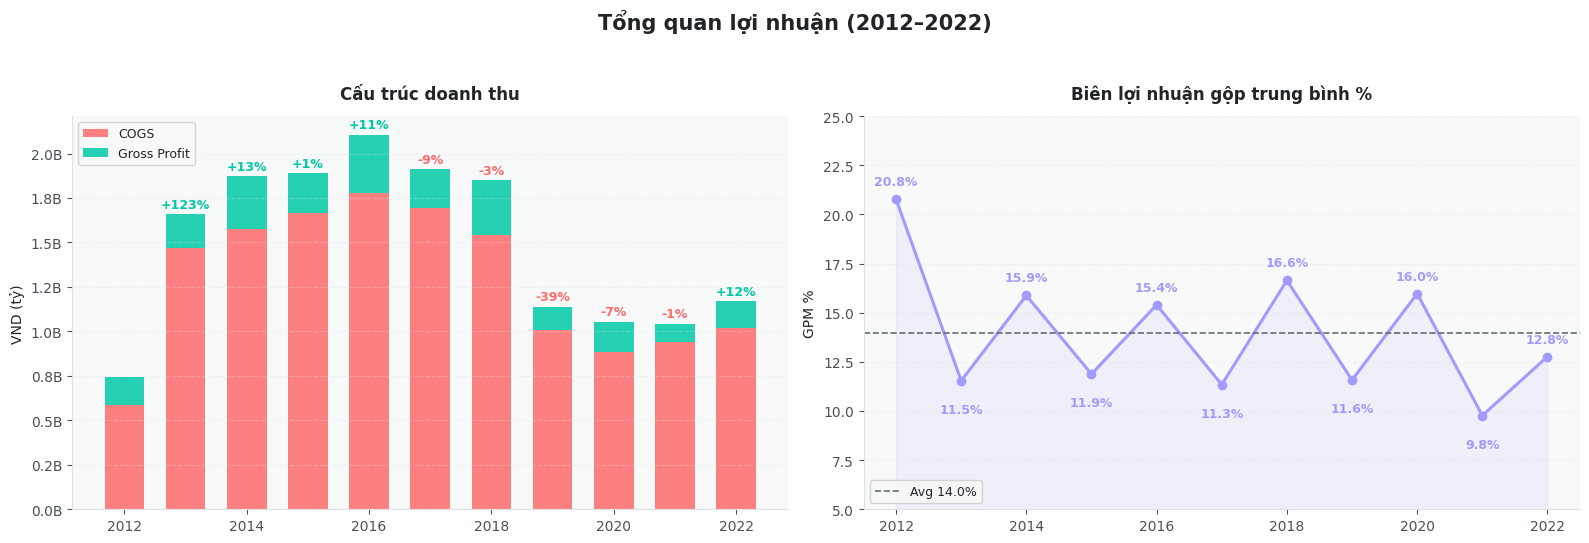

,year,Revenue,COGS,Gross_Profit,GM%,YoY%,Disc%
0,2012,"741,497,748","587,461,924","154,035,824",20.8%,+nan%,0.00%
1,2013,"1,657,169,417","1,465,980,103","191,189,314",11.5%,+123.5%,5.25%
2,2014,"1,871,845,883","1,574,607,457","297,238,426",15.9%,+13.0%,4.62%
3,2015,"1,889,933,827","1,665,441,817","224,492,010",11.9%,+1.0%,5.18%
4,2016,"2,104,640,678","1,780,559,393","324,081,285",15.4%,+11.4%,4.38%
5,2017,"1,911,164,325","1,694,385,794","216,778,532",11.3%,-9.2%,5.00%
6,2018,"1,850,122,456","1,542,175,766","307,946,690",16.6%,-3.2%,4.35%
7,2019,"1,136,801,442","1,005,202,884","131,598,558",11.6%,-38.6%,4.86%
8,2020,"1,054,512,159","886,085,098","168,427,061",16.0%,-7.2%,4.59%
9,2021,"1,043,039,820","941,130,120","101,909,699",9.8%,-1.1%,4.97%


In [ ]:
# Formula A
annual = sales.groupby('year').agg(Revenue=('Revenue','sum'), COGS=('COGS','sum')).reset_index()
annual['Gross_Profit']  = annual['Revenue'] - annual['COGS']
annual['GP_Margin_pct'] = annual['Gross_Profit'] / annual['Revenue'] * 100
annual['Rev_YoY']       = annual['Revenue'].pct_change() * 100

annual_disc = oi_prod.groupby('year').agg(
    total_discount=('discount_amount','sum'),
    gross_rev=('gross_revenue','sum')
).reset_index()
annual_disc['disc_rate'] = annual_disc['total_discount'] / annual_disc['gross_rev'] * 100
annual = annual.merge(annual_disc[['year','disc_rate','total_discount']], on='year', how='left')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('Tổng quan lợi nhuận (2012–2022)',
             fontsize=15, fontweight='bold', color='#212529', y=0.98)
fig.patch.set_facecolor('white')

years = annual['year'].values

# (A) Stacked bar
bar_w = 0.65
ax1.bar(years, annual['COGS']/1e9, bar_w, label='COGS', color=C['red'], alpha=0.85)
ax1.bar(years, annual['Gross_Profit']/1e9, bar_w, bottom=annual['COGS']/1e9,
        label='Gross Profit', color=C['teal'], alpha=0.85)
for yr, yoy, rev in zip(years, annual['Rev_YoY'].fillna(float('nan')), annual['Revenue']/1e9):
    if not np.isnan(yoy):
        clr = C['teal'] if yoy >= 0 else C['red']
        ax1.text(yr, rev + 0.02, f'{yoy:+.0f}%', ha='center', va='bottom',
                 fontsize=9, color=clr, fontweight='bold')

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x:.1f}B'))
ax1.set_title('Cấu trúc doanh thu', color='#212529', fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel('VND (tỷ)')
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.legend(fontsize=9, loc='upper left')
ax1.set_facecolor('#F8F9F9')

# (B) Gross Profit Margin %
ax2.plot(years, annual['GP_Margin_pct'], marker='o', color=C['purple'], lw=2.2, ms=6)
ax2.fill_between(years, annual['GP_Margin_pct'], alpha=0.1, color=C['purple'])
for i, (x, y) in enumerate(zip(years, annual['GP_Margin_pct'])):
    offset, va = (8, 'bottom') if i % 2 == 0 else (-16, 'top')
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, offset),
                 ha='center', va=va, fontsize=9, color=C['purple'], fontweight='bold')

avg_gm = annual['GP_Margin_pct'].mean()
ax2.axhline(avg_gm, color=C['grey'], lw=1.2, ls='--', label=f'Avg {avg_gm:.1f}%')

ax2.set_title('Biên lợi nhuận gộp trung bình %', color='#212529', fontsize=12, fontweight='bold', pad=12)
ax2.set_ylabel('GPM %')
ax2.set_ylim(5, 25) # Thu gọn khoảng trống thừa phía trên
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.legend(fontsize=9, loc='lower left')
ax2.set_facecolor('#F8F9F9')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

#Bảng tổng hợp
display(annual[['year','Revenue','COGS','Gross_Profit','GP_Margin_pct','Rev_YoY','disc_rate']]
        .rename(columns={'GP_Margin_pct':'GM%','Rev_YoY':'YoY%','disc_rate':'Disc%'})
        .style.format({
            'Revenue':'{:,.0f}','COGS':'{:,.0f}','Gross_Profit':'{:,.0f}',
            'GM%':'{:.1f}%','YoY%':'{:+.1f}%','Disc%':'{:.2f}%'
        })
)

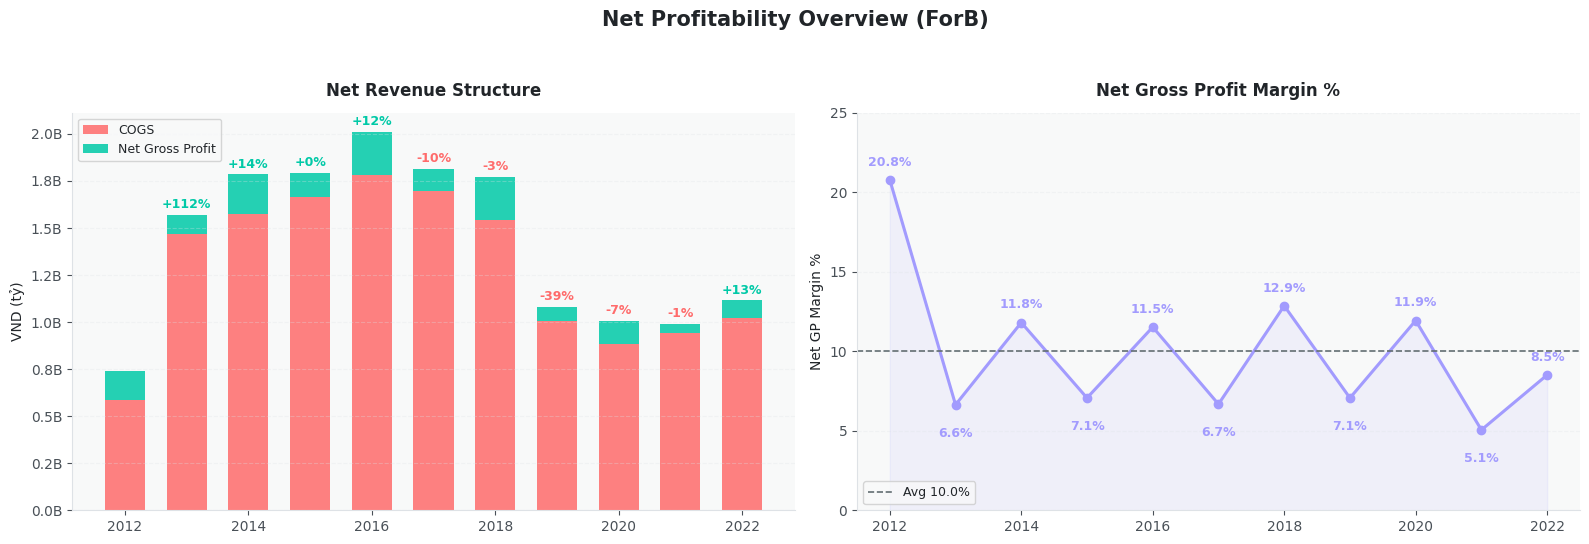

In [ ]:
# Formula B
annual['Net_Revenue'] = annual['Revenue'] - annual['total_discount']
annual['Net_Gross_Profit'] = annual['Net_Revenue'] - annual['COGS']
annual['Net_GP_Margin_pct'] = annual['Net_Gross_Profit'] / annual['Net_Revenue'] * 100
annual['Net_Rev_YoY'] = annual['Net_Revenue'].pct_change() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('Net Profitability Overview (ForB)',
             fontsize=15, fontweight='bold', color='#212529', y=0.98)
fig.patch.set_facecolor('white')

years = annual['year'].values

# (A) Stacked bar
bar_w = 0.65
ax1.bar(years, annual['COGS']/1e9, bar_w, label='COGS', color=C['red'], alpha=0.85)
ax1.bar(years, annual['Net_Gross_Profit']/1e9, bar_w, bottom=annual['COGS']/1e9,
        label='Net Gross Profit', color=C['teal'], alpha=0.85)

for yr, yoy, rev in zip(years, annual['Net_Rev_YoY'].fillna(float('nan')), annual['Net_Revenue']/1e9):
    if not np.isnan(yoy):
        clr = C['teal'] if yoy >= 0 else C['red']
        ax1.text(yr, rev + 0.02, f'{yoy:+.0f}%', ha='center', va='bottom',
                 fontsize=9, color=clr, fontweight='bold')

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x:.1f}B'))
ax1.set_title('Net Revenue Structure', color='#212529', fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel('VND (tỷ)')
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.legend(fontsize=9, loc='upper left')
ax1.set_facecolor('#F8F9F9')

# (B) Line Chart
ax2.plot(years, annual['Net_GP_Margin_pct'], marker='o', color=C['purple'], lw=2.2, ms=6)
ax2.fill_between(years, annual['Net_GP_Margin_pct'], alpha=0.1, color=C['purple'])

for i, (x, y) in enumerate(zip(years, annual['Net_GP_Margin_pct'])):
    offset, va = (8, 'bottom') if i % 2 == 0 else (-16, 'top')
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, offset),
                 ha='center', va=va, fontsize=9, color=C['purple'], fontweight='bold')

avg_net_gm = annual['Net_GP_Margin_pct'].mean()
ax2.axhline(avg_net_gm, color=C['grey'], lw=1.2, ls='--', label=f'Avg {avg_net_gm:.1f}%')

ax2.set_title('Net Gross Profit Margin %', color='#212529', fontsize=12, fontweight='bold', pad=12)
ax2.set_ylabel('Net GP Margin %')
ax2.set_ylim(0, 25)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.legend(fontsize=9, loc='lower left')
ax2.set_facecolor('#F8F9F9')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


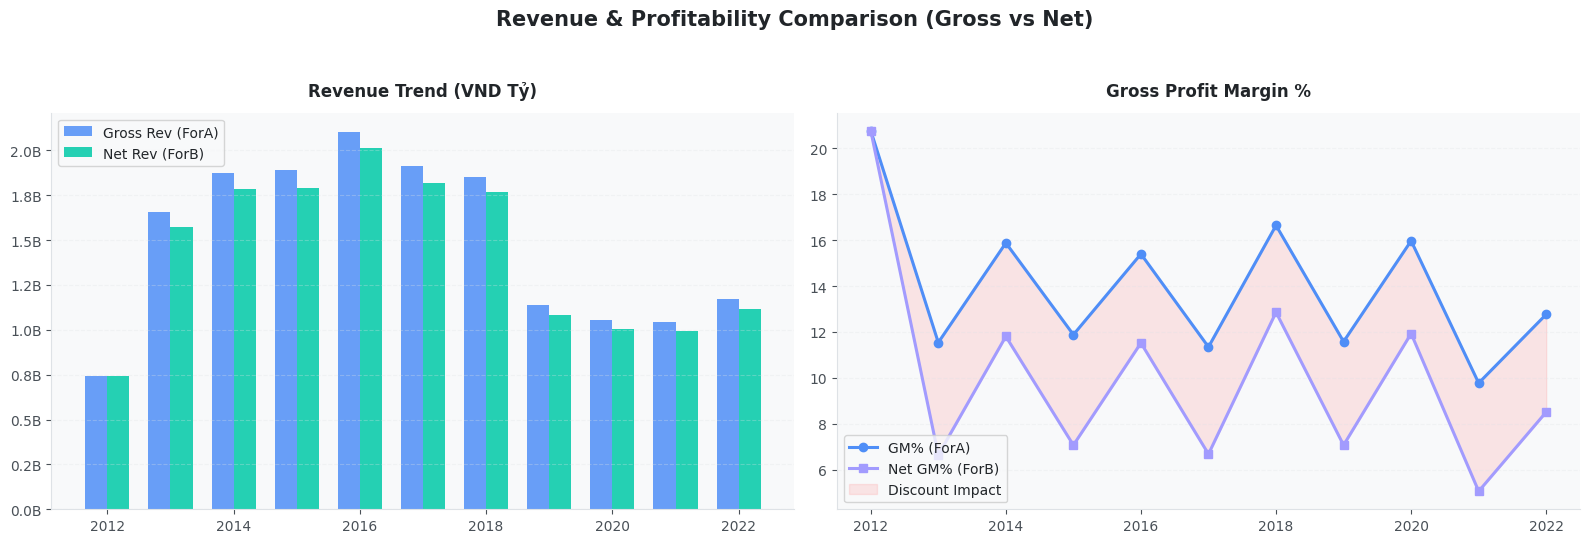

In [ ]:
# 1. Đảm bảo các chỉ số ForB đã được tính toán
annual['Net_Revenue'] = annual['Revenue'] - annual['total_discount']
annual['Net_Gross_Profit'] = annual['Net_Revenue'] - annual['COGS']
annual['Net_GP_Margin_pct'] = annual['Net_Gross_Profit'] / annual['Net_Revenue'] * 100

# 2. Tạo khung biểu đồ với 2 đồ thị (subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('Revenue & Profitability Comparison (Gross vs Net)',
             fontsize=15, fontweight='bold', color='#212529', y=0.98)
fig.patch.set_facecolor('white')

years = annual['year'].values
bar_w = 0.35
# CHART A Grouped Bar Chart
ax1.bar(years - bar_w/2, annual['Revenue']/1e9, bar_w, label='Gross Rev (ForA)', color=C['blue'], alpha=0.85)
ax1.bar(years + bar_w/2, annual['Net_Revenue']/1e9, bar_w, label='Net Rev (ForB)', color=C['teal'], alpha=0.85)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x:.1f}B'))
ax1.set_title('Revenue Trend (VND Tỷ)', color='#212529', fontsize=12, fontweight='bold', pad=12)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.legend(fontsize=10, loc='upper left')

# CHART B: Line Chart
ax2.plot(years, annual['GP_Margin_pct'], marker='o', color=C['blue'], lw=2.2, ms=6, label='GM% (ForA)')
ax2.plot(years, annual['Net_GP_Margin_pct'], marker='s', color=C['purple'], lw=2.2, ms=6, label='Net GM% (ForB)')

ax2.fill_between(years, annual['Net_GP_Margin_pct'], annual['GP_Margin_pct'], alpha=0.15, color=C['red'], label='Discount Impact')

ax2.set_title('Gross Profit Margin %', color='#212529', fontsize=12, fontweight='bold', pad=12)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.legend(fontsize=10, loc='lower left')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


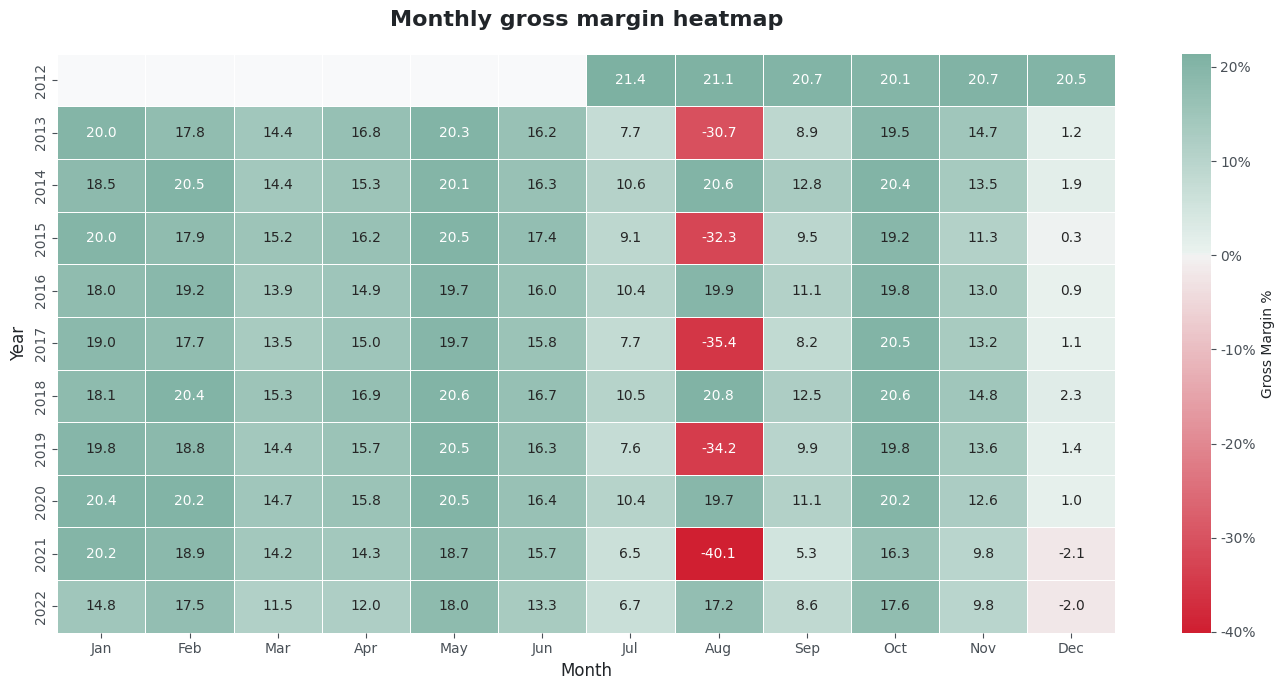

In [ ]:
monthly_data = sales.groupby(['year', 'month']).agg(
    Revenue=('Revenue', 'sum'),
    COGS=('COGS', 'sum')
).reset_index()

monthly_data['GM_pct'] = (monthly_data['Revenue'] - monthly_data['COGS']) / monthly_data['Revenue'] * 100

heatmap_df = monthly_data.pivot(index='year', columns='month', values='GM_pct')

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_df.columns = month_names
plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_df,
            annot=True,
            fmt=".1f",
            cmap=sns.diverging_palette(10, 160, s=90, l=45, n=7, as_cmap=True),
            center=0,
            linewidths=.5,
            cbar_kws={'label': 'Gross Margin %', 'format': mticker.FormatStrFormatter('%.0f%%')})

plt.title('Monthly gross margin heatmap',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)

plt.tight_layout()
plt.show()

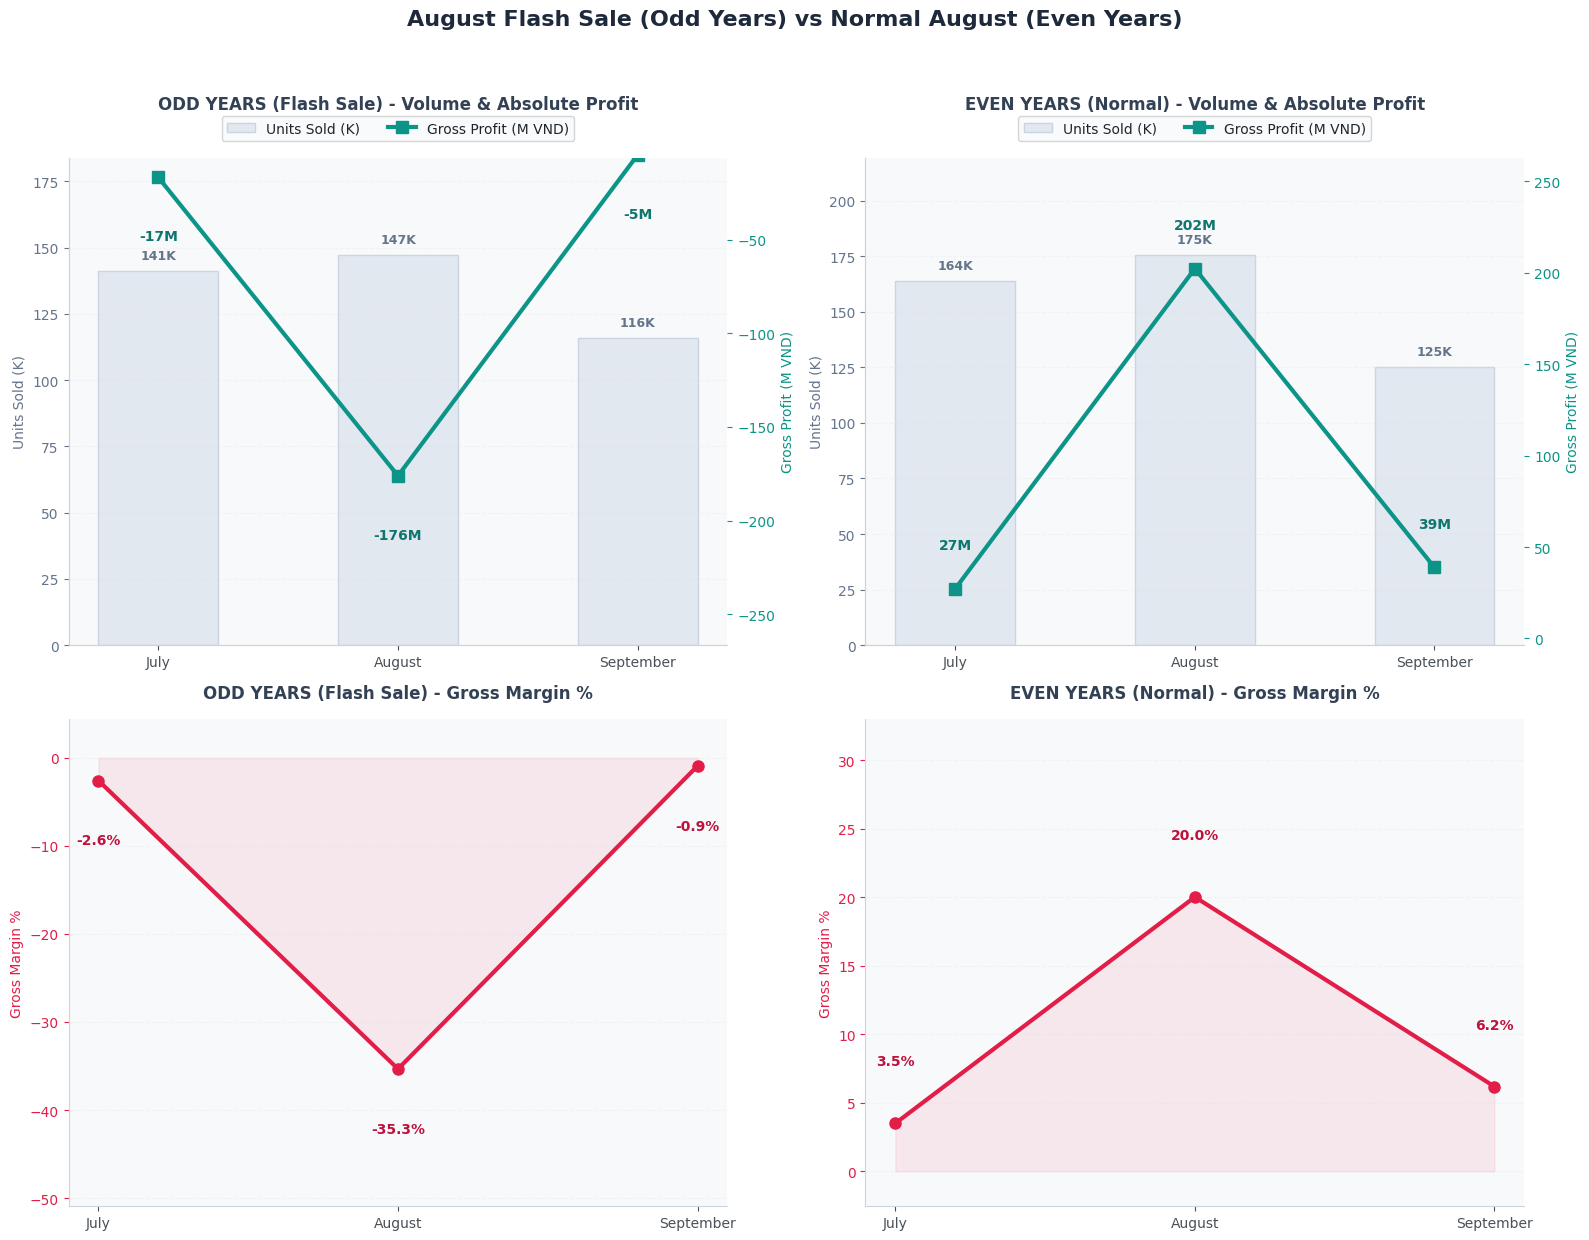

In [ ]:
oi_prod['year_type'] = np.where(oi_prod['year'] % 2 != 0, 'Odd Years (Flash Sale)', 'Even Years (No Sale)')

summer_split = oi_prod[oi_prod['month'].isin([7, 8, 9])]

split_roi = summer_split.groupby(['year_type', 'month']).agg(
    units_sold=('quantity', 'sum'),
    total_net_rev=('net_revenue', 'sum'),
    total_cogs=('cogs_total', 'sum')
).reset_index()

split_roi['gross_profit'] = split_roi['total_net_rev'] - split_roi['total_cogs']
split_roi['gm_pct'] = split_roi['gross_profit'] / split_roi['total_net_rev'] * 100

month_labels = {7: 'July', 8: 'August', 9: 'September'}
split_roi['month_label'] = split_roi['month'].map(month_labels)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('August Flash Sale (Odd Years) vs Normal August (Even Years)', fontsize=16, fontweight='bold', y=1.03, color='#1E293B')
fig.patch.set_facecolor('white')

odd_data = split_roi[split_roi['year_type'] == 'Odd Years (Flash Sale)']
even_data = split_roi[split_roi['year_type'] == 'Even Years (No Sale)']

c_bar = '#E2E8F0'
c_line_profit = '#0D9488'
c_line_margin = '#E11D48'

def plot_roi_subplot(ax_bar, ax_margin, data, title):
    ax_bar.bar(data['month_label'], data['units_sold']/1000, color=c_bar, edgecolor='#CBD5E1', width=0.5, label='Units Sold (K)')
    ax_twin = ax_bar.twinx()
    ax_twin.plot(data['month_label'], data['gross_profit']/1e6, color=c_line_profit, marker='s', lw=3, ms=8, label='Gross Profit (M VND)')

    ax_bar.set_title(f"{title} - Volume & Absolute Profit", fontsize=12, fontweight='bold', pad=35, color='#334155')
    ax_bar.set_ylabel('Units Sold (K)', color='#64748B')
    ax_twin.set_ylabel('Gross Profit (M VND)', color=c_line_profit)
    ax_bar.grid(axis='y', linestyle='--', alpha=0.3)
    ax_bar.tick_params(axis='y', colors='#64748B')
    ax_twin.tick_params(axis='y', colors=c_line_profit)

    h1, l1 = ax_bar.get_legend_handles_labels()
    h2, l2 = ax_twin.get_legend_handles_labels()
    ax_bar.legend(h1+h2, l1+l2, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=10, frameon=True)

    for x, y in zip(data['month_label'], data['units_sold']/1000):
        ax_bar.text(x, y + (data['units_sold'].max()/1000 * 0.03), f"{y:.0f}K", ha='center', fontsize=9, fontweight='bold', color='#64748B')

    for x, y in zip(data['month_label'], data['gross_profit']/1e6):
        # Dùng khoảng cách cứng dựa trên scale của biểu đồ thay vì số tuyệt đối
        offset = abs(data['gross_profit'].max()/1e6)*0.1 if y > 0 else -abs(data['gross_profit'].min()/1e6)*0.1 - 10
        va = 'bottom' if y > 0 else 'top'
        ax_twin.text(x, y + offset, f"{y:.0f}M", ha='center', va=va, fontsize=10, fontweight='bold', color='#0F766E')

    margin_min, margin_max = data['gross_profit'].min()/1e6, data['gross_profit'].max()/1e6
    ax_twin.set_ylim(margin_min - abs(margin_min)*0.4 - 20, margin_max * 1.3)
    ax_bar.set_ylim(0, data['units_sold'].max()/1000 * 1.25)

    ax_margin.plot(data['month_label'], data['gm_pct'], color=c_line_margin, marker='o', lw=3, ms=8)
    ax_margin.fill_between(data['month_label'], data['gm_pct'], alpha=0.08, color=c_line_margin)

    ax_margin.set_title(f"{title} - Gross Margin %", fontsize=12, fontweight='bold', pad=15, color='#334155')
    ax_margin.set_ylabel('Gross Margin %', color=c_line_margin)
    ax_margin.grid(axis='y', linestyle='--', alpha=0.3)
    ax_margin.tick_params(axis='y', colors=c_line_margin)

    for x, y in zip(data['month_label'], data['gm_pct']):
        offset = 4 if y > 0 else -6
        va = 'bottom' if y > 0 else 'top'
        ax_margin.annotate(f"{y:.1f}%", (x, y + offset), ha='center', va=va, fontsize=10, fontweight='bold', color='#BE123C')

    gm_min, gm_max = data['gm_pct'].min(), data['gm_pct'].max()
    ax_margin.set_ylim(gm_min - abs(gm_min)*0.3 - 5, gm_max + abs(gm_max)*0.4 + 5)

    # Thẩm mỹ viền
    for ax in [ax_bar, ax_twin, ax_margin]:
        ax.spines['top'].set_visible(False)
        if ax != ax_bar: ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#CBD5E1')
        ax.spines['bottom'].set_color('#CBD5E1')

plot_roi_subplot(axes[0, 0], axes[1, 0], odd_data, 'ODD YEARS (Flash Sale)')
plot_roi_subplot(axes[0, 1], axes[1, 1], even_data, 'EVEN YEARS (Normal)')

plt.tight_layout()
plt.show()

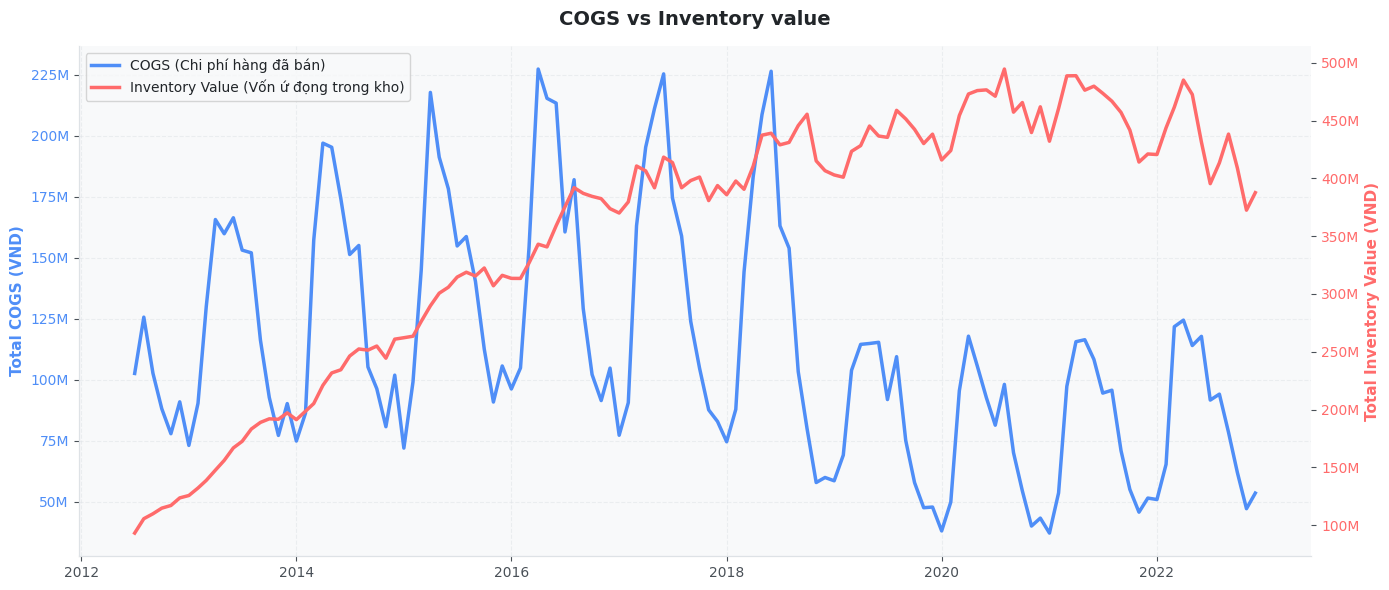

In [ ]:
# COGS vs. Inventory Value
oi_prod['ym'] = oi_prod['order_date'].dt.to_period('M')
monthly_cogs = oi_prod.groupby('ym')['cogs_total'].sum().reset_index()
monthly_cogs['Date'] = monthly_cogs['ym'].dt.to_timestamp()

inv_val = inventory.merge(products[['product_id', 'cogs']], on='product_id', how='left')
inv_val['inventory_value'] = inv_val['stock_on_hand'] * inv_val['cogs']
inv_val['ym'] = inv_val['snapshot_date'].dt.to_period('M')
monthly_inv = inv_val.groupby('ym')['inventory_value'].sum().reset_index()
monthly_inv['Date'] = monthly_inv['ym'].dt.to_timestamp()

trend_df = monthly_cogs.merge(monthly_inv, on='Date', how='outer').sort_values('Date')

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(trend_df['Date'], trend_df['cogs_total'], color=C['blue'], lw=2.5, label='COGS (Chi phí hàng đã bán)')
ax1.set_ylabel('Total COGS (VND)', color=C['blue'], fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=C['blue'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_b))

ax2 = ax1.twinx()
ax2.plot(trend_df['Date'], trend_df['inventory_value'], color=C['red'], lw=2.5, label='Inventory Value (Vốn ứ đọng trong kho)')
ax2.set_ylabel('Total Inventory Value (VND)', color=C['red'], fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=C['red'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_b))

plt.title('COGS vs Inventory value', fontsize=14, fontweight='bold', pad=15)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## LAYER 2 - order analysis

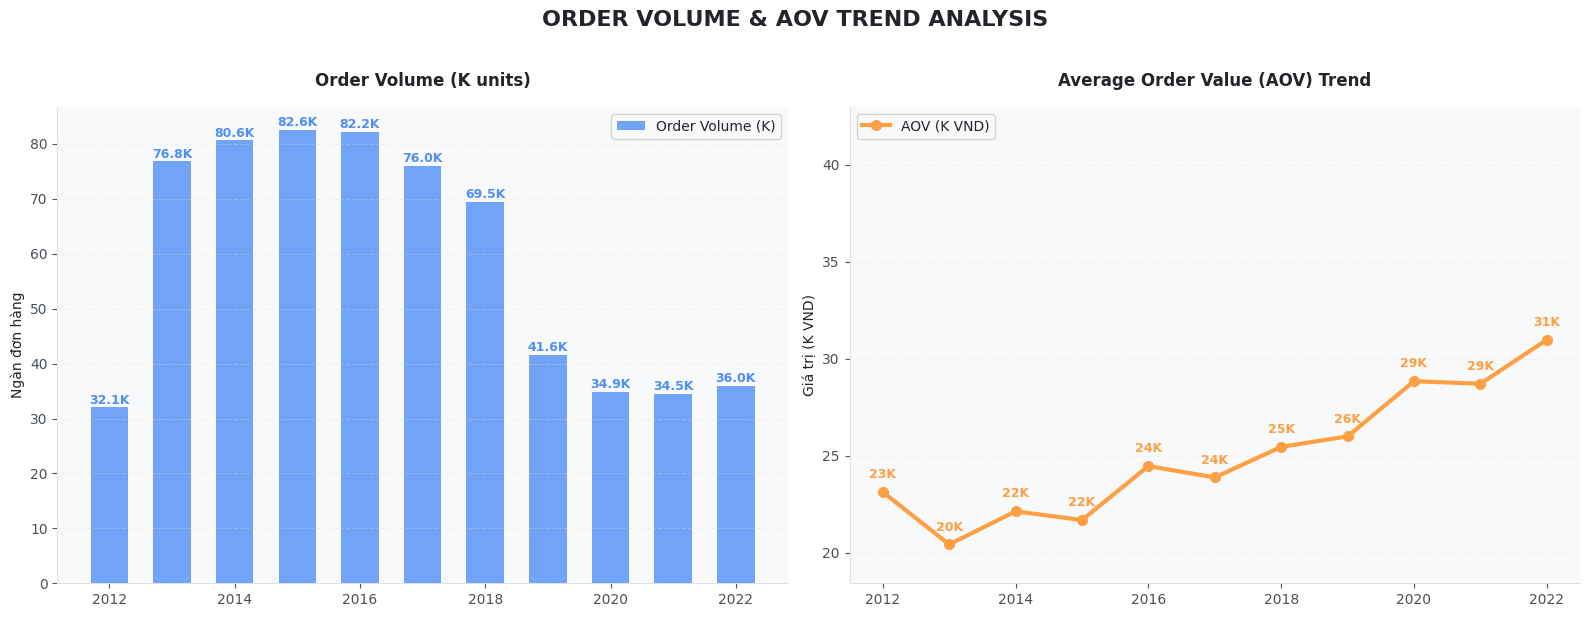

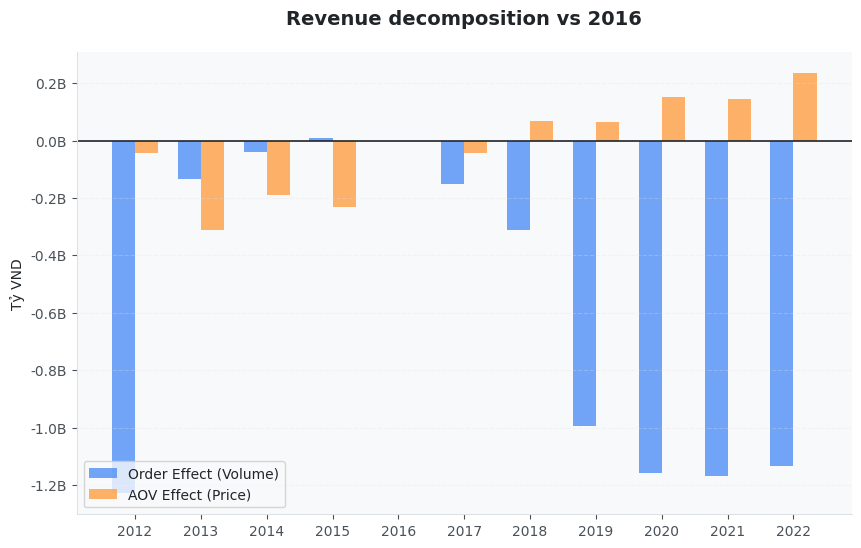

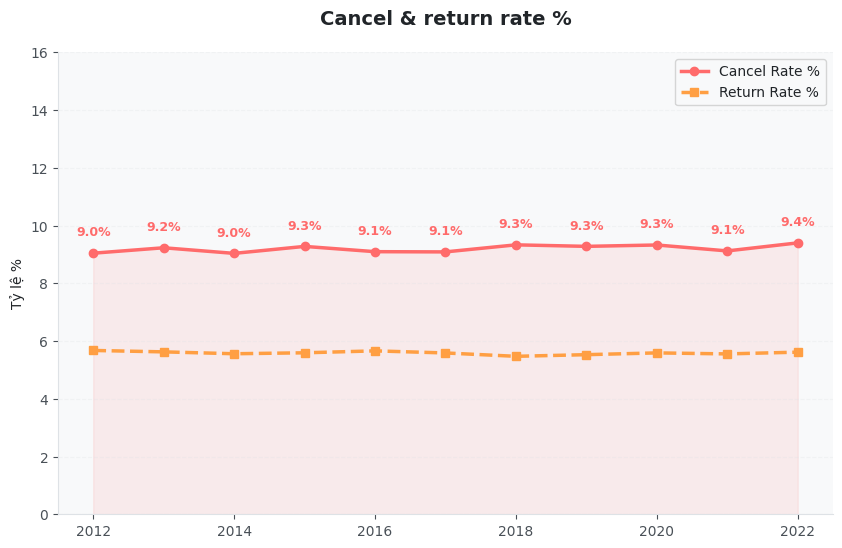

In [ ]:
orders_merged = orders.merge(payments[['order_id','payment_value']], on='order_id', how='left')

annual_orders = orders_merged.groupby('year').agg(
    total_orders=('order_id', 'count'),
    avg_aov=('payment_value', 'mean'),
    total_gmv=('payment_value', 'sum')
).reset_index()

status_yr = orders.groupby(['year', 'order_status']).size().unstack(fill_value=0)
status_yr['cancel_rate'] = status_yr.get('cancelled', 0) / status_yr.sum(axis=1) * 100
status_yr['return_rate'] = status_yr.get('returned', 0) / status_yr.sum(axis=1) * 100
annual_orders = annual_orders.merge(status_yr[['cancel_rate', 'return_rate']].reset_index(), on='year')

base_yr = annual_orders[annual_orders['year'] == 2016].iloc[0]
Q_base, P_base = base_yr['total_orders'], base_yr['avg_aov']
annual_orders['order_effect'] = (annual_orders['total_orders'] - Q_base) * P_base
annual_orders['aov_effect']   = annual_orders['total_orders'] * (annual_orders['avg_aov'] - P_base)

yrs = annual_orders['year'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ORDER VOLUME & AOV TREND ANALYSIS', fontsize=16, fontweight='bold', y=1.02)

# Volume
ax1.bar(yrs, annual_orders['total_orders']/1000, color=C['blue'], alpha=0.8, width=0.6, label='Order Volume (K)')
for x, y in zip(yrs, annual_orders['total_orders']/1000):
    ax1.text(x, y + 0.1, f'{y:.1f}K', ha='center', va='bottom', fontsize=9, fontweight='bold', color=C['blue'])
ax1.set_title('Order Volume (K units)', fontsize=12, fontweight='bold', pad=15)
ax1.set_ylabel('Ngàn đơn hàng')
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.legend(loc='upper right')

# AOV
aov_k = annual_orders['avg_aov']/1000
ax2.plot(yrs, aov_k, color=C['orange'], marker='o', lw=3, ms=7, label='AOV (K VND)')
for x, y in zip(yrs, aov_k):
    ax2.annotate(f'{y:.0f}K', (x, y), textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=9, fontweight='bold', color=C['orange'])
ax2.set_title('Average Order Value (AOV) Trend', fontsize=12, fontweight='bold', pad=15)
ax2.set_ylabel('Giá trị (K VND)')
# Bóp scale cực sát: đáy -2 đơn vị, đỉnh +12 đơn vị (để hiện label)
ax2.set_ylim(aov_k.min() - 2, aov_k.max() + 12)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Revenue Decomposition
plt.figure(figsize=(10, 6))
w = 0.35
pos = np.arange(len(annual_orders))

# Order Effect fix cứng màu Blue (đồng bộ với Volume)
plt.bar(pos - w/2, annual_orders['order_effect']/1e9, w,
        color=C['blue'], alpha=0.8, label='Order Effect (Volume)')

# AOV Effect fix cứng màu Orange (đồng bộ với AOV trend)
plt.bar(pos + w/2, annual_orders['aov_effect']/1e9, w,
        color=C['orange'], alpha=0.8, label='AOV Effect (Price)')

plt.axhline(0, color='#212529', lw=1.2)
plt.xticks(pos, annual_orders['year'])
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x:.1f}B'))
plt.title('Revenue decomposition vs 2016', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Tỷ VND')

# Legend đặt ở dưới để không đè vào bar
plt.legend(loc='lower left', fontsize=10, frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# Cancel & Return Rate
plt.figure(figsize=(10, 6))
plt.plot(yrs, annual_orders['cancel_rate'], marker='o', color=C['red'], lw=2.5, label='Cancel Rate %')
plt.plot(yrs, annual_orders['return_rate'], marker='s', color=C['orange'], lw=2.5, ls='--', label='Return Rate %')
plt.fill_between(yrs, annual_orders['cancel_rate'], alpha=0.1, color=C['red'])
for x, y in zip(yrs, annual_orders['cancel_rate']):
    plt.text(x, y + 0.6, f'{y:.1f}%', ha='center', fontsize=9, color=C['red'], fontweight='bold')
plt.title('Cancel & return rate %', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Tỷ lệ %')
plt.ylim(0, 16)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper right')
plt.show()

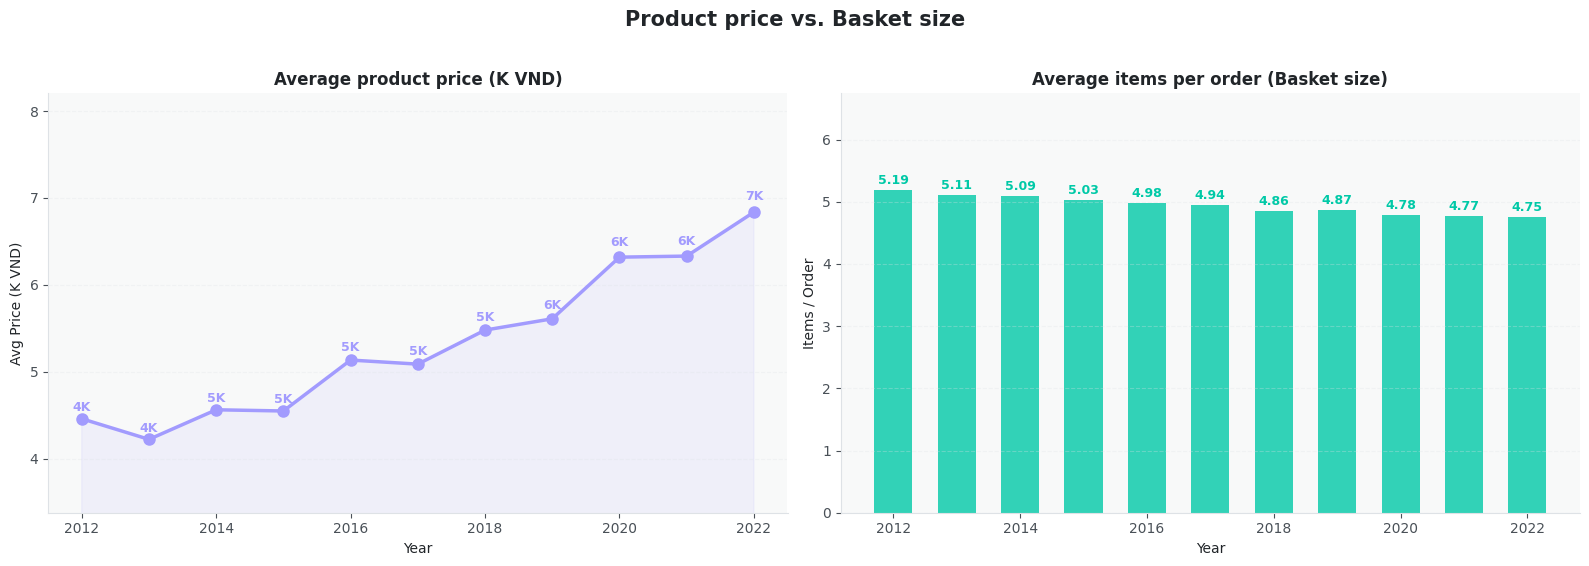

In [ ]:
basket_yr = oi_prod.groupby('year').agg(
    total_quantity=('quantity', 'sum'),
    total_revenue=('gross_revenue', 'sum'),
    total_orders=('order_id', 'nunique')
).reset_index()

basket_yr['avg_items_per_order'] = basket_yr['total_quantity'] / basket_yr['total_orders']
basket_yr['avg_unit_price'] = basket_yr['total_revenue'] / basket_yr['total_quantity']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('Product price vs. Basket size', fontsize=15, fontweight='bold', y=1.02)
fig.patch.set_facecolor('white')

# (1) Chart 1: Average Unit Price (Line Chart)
ax1.plot(basket_yr['year'], basket_yr['avg_unit_price']/1000, marker='o', lw=2.5, ms=8, color=C['purple'], label='Avg Unit Price')
ax1.fill_between(basket_yr['year'], basket_yr['avg_unit_price']/1000, alpha=0.1, color=C['purple'])
for x, y in zip(basket_yr['year'], basket_yr['avg_unit_price']/1000):
    ax1.annotate(f'{y:.0f}K', (x, y + (y * 0.02)), ha='center', fontsize=9, color=C['purple'], fontweight='bold')

ax1.set_title('Average product price (K VND)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Avg Price (K VND)')
ax1.set_xlabel('Year')
ax1.set_ylim((basket_yr['avg_unit_price'].min()/1000) * 0.8, (basket_yr['avg_unit_price'].max()/1000) * 1.2)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.set_facecolor('#F8F9F9')

# (2) Chart 2: Items per Order / Basket Size (Bar Chart)
ax2.bar(basket_yr['year'], basket_yr['avg_items_per_order'], color=C['teal'], alpha=0.8, width=0.6)
for x, y in zip(basket_yr['year'], basket_yr['avg_items_per_order']):
    ax2.annotate(f'{y:.2f}', (x, y + 0.05), ha='center', va='bottom', fontsize=9, color=C['teal'], fontweight='bold')

ax2.set_title('Average items per order (Basket size)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Items / Order')
ax2.set_xlabel('Year')
ax2.set_ylim(0, basket_yr['avg_items_per_order'].max() * 1.3)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.set_facecolor('#F8F9F9')

plt.tight_layout()
plt.show()

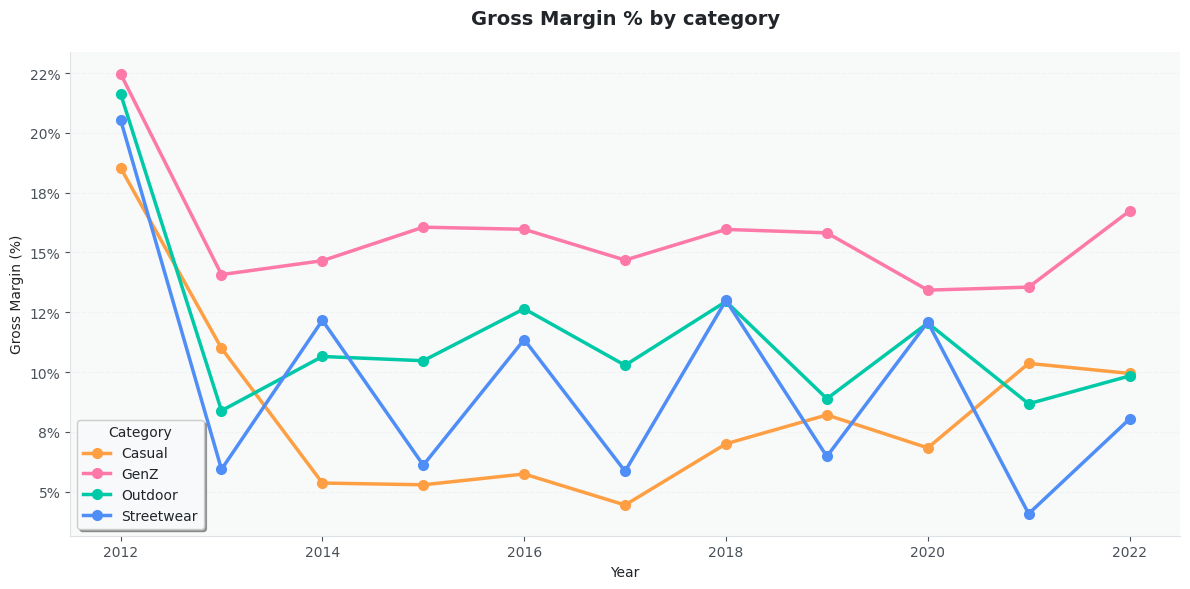

In [ ]:
# ── 2-D: Gross Margin % By Category ───────────────────────────────────────
# Tính doanh thu thuần và giá vốn cho từng nhóm ngành hàng qua các năm
cat_margin_yr = oi_prod.groupby(['year', 'category']).agg(
    total_revenue=('net_revenue', 'sum'),
    total_cogs=('cogs_total', 'sum')
).reset_index()

# Tính tỷ suất lợi nhuận gộp (GM%)
cat_margin_yr['GM_pct'] = (cat_margin_yr['total_revenue'] - cat_margin_yr['total_cogs']) / cat_margin_yr['total_revenue'] * 100

cat_gm_pivot = cat_margin_yr.pivot(index='year', columns='category', values='GM_pct').dropna()

cat_colors = {
    'Streetwear': C['blue'],
    'Outdoor': C['teal'],
    'Casual': C['orange'],
    'GenZ': C['pink']
}

plt.figure(figsize=(12, 6))
ax = plt.gca()

years = cat_gm_pivot.index

# Vẽ đường line cho từng mảng
for cat in cat_gm_pivot.columns:
    ax.plot(years, cat_gm_pivot[cat], marker='o', lw=2.5, ms=7,
            color=cat_colors.get(cat, C['grey']), label=cat)

# Làm đẹp biểu đồ
ax.set_title('Gross Margin % by category', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Gross Margin (%)')
ax.set_xlabel('Year')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))

ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_facecolor('#F8F9F9')
ax.legend(loc='lower left', fontsize=10, title="Category", frameon=True, shadow=True)

plt.tight_layout()
plt.show()

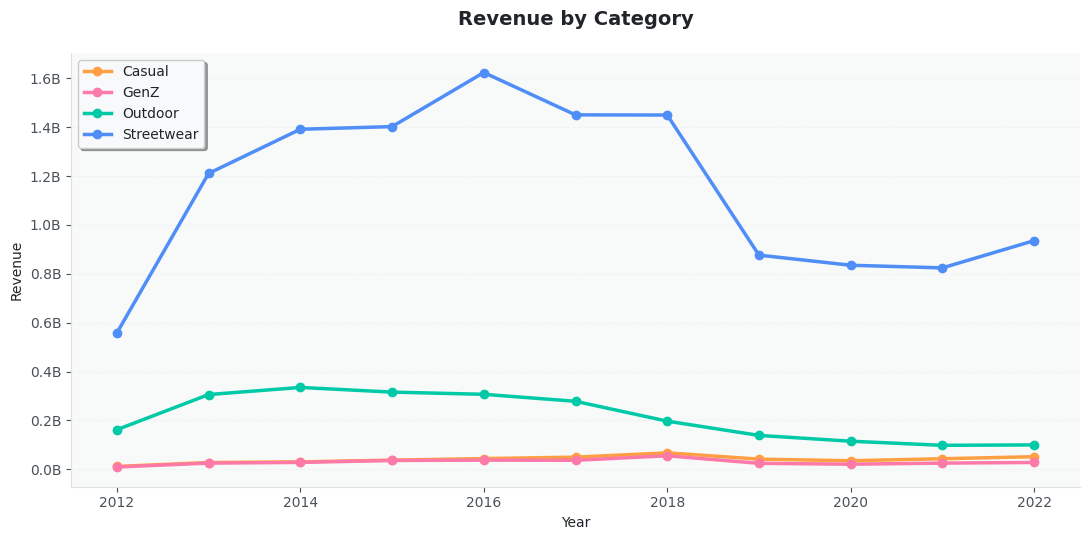

In [ ]:
cat_yr = oi_prod.groupby(['year','category']).agg(
    revenue=('net_revenue','sum'),
    orders=('order_id','nunique')
).reset_index()

cat_pivot = cat_yr.pivot(index='year', columns='category', values='revenue').fillna(0)
cat_pct   = cat_pivot.div(cat_pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(11, 5.5))
ax = plt.gca()

years = cat_pivot.index

for cat in cat_pivot.columns:
    ax.plot(years, cat_pivot[cat]/1e9, marker='o', lw=2.5, ms=6,
            color=cat_colors.get(cat, C['grey']), label=cat)

# Định dạng và thẩm mỹ
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x:.1f}B'))
ax.set_title('Revenue by Category', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Revenue')
ax.set_xlabel('Year')

ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_facecolor('#F8F9F9')

ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

plt.tight_layout()
plt.show()


## LAYER 3 - customer analysis

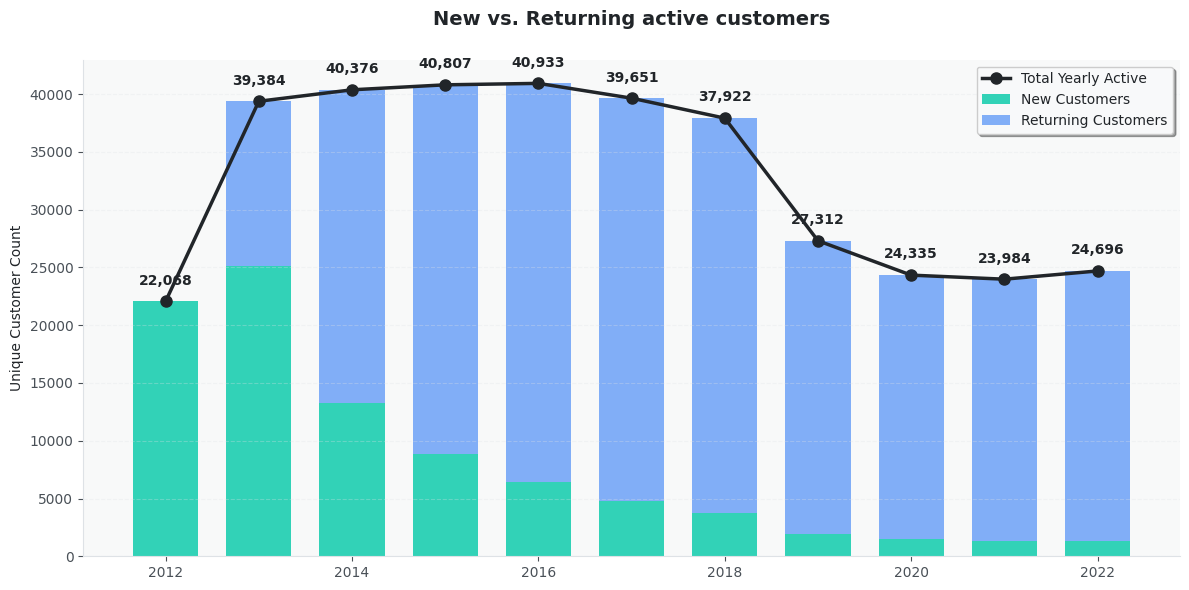

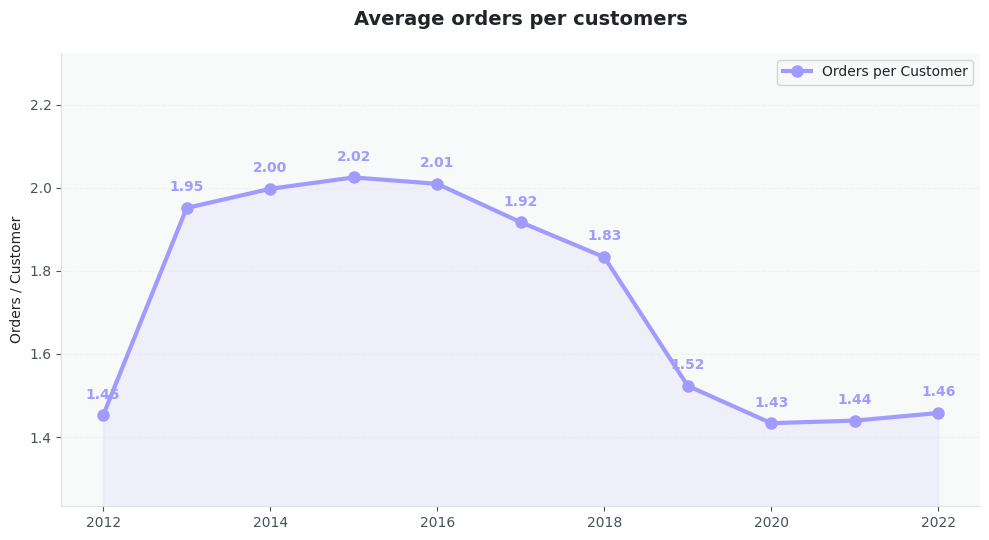

In [ ]:
# Khách hàng Active thực tế mỗi năm
yearly_active = orders.groupby('year')['customer_id'].nunique().reset_index(name='total_active')

# Khách hàng MỚI (Dựa trên năm đầu tiên mua hàng)
first_order = orders.groupby('customer_id')['order_date'].min().reset_index()
first_order['first_year'] = first_order['order_date'].dt.year
new_cust = first_order.groupby('first_year').size().reset_index(name='new_customers')

df_cust = pd.merge(yearly_active, new_cust, left_on='year', right_on='first_year', how='left')
df_cust['returning_customers'] = df_cust['total_active'] - df_cust['new_customers']

order_counts = orders.groupby('year').size().reset_index(name='total_orders')
df_cust = df_cust.merge(order_counts, on='year')
df_cust['orders_per_cust'] = df_cust['total_orders'] / df_cust['total_active']

yrs = df_cust['year'].values

# Real Annual Active Customers
plt.figure(figsize=(12, 6))
ax = plt.gca()

ax.bar(yrs, df_cust['new_customers'], color=C['teal'], alpha=0.8, label='New Customers', width=0.7)
ax.bar(yrs, df_cust['returning_customers'], bottom=df_cust['new_customers'],
       color=C['blue'], alpha=0.7, label='Returning Customers', width=0.7)

ax.plot(yrs, df_cust['total_active'], marker='o', color='#212529', linewidth=2.5,
        ms=8, label='Total Yearly Active')

for x, y in zip(yrs, df_cust['total_active']):
    ax.annotate(f"{int(y):,}", xy=(x, y), textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold', color='#212529')

ax.set_title('New vs. Returning active customers', fontsize=14, fontweight='bold', pad=25)
ax.set_ylabel('Unique Customer Count')
ax.set_facecolor('#F8F9F9')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# Orders per Active Customer
plt.figure(figsize=(10, 5.5))
ax = plt.gca()

ax.plot(yrs, df_cust['orders_per_cust'], marker='o', color=C['purple'], lw=3, ms=8, label='Orders per Customer')
ax.fill_between(yrs, df_cust['orders_per_cust'], 1, alpha=0.1, color=C['purple'])

for x, y in zip(yrs, df_cust['orders_per_cust']):
    ax.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold', color=C['purple'])

ax.set_title('Average orders per customers', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Orders / Customer')
ax.set_ylim(min(df_cust['orders_per_cust']) - 0.2, max(df_cust['orders_per_cust']) + 0.3)
ax.set_facecolor('#F8F9F9')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

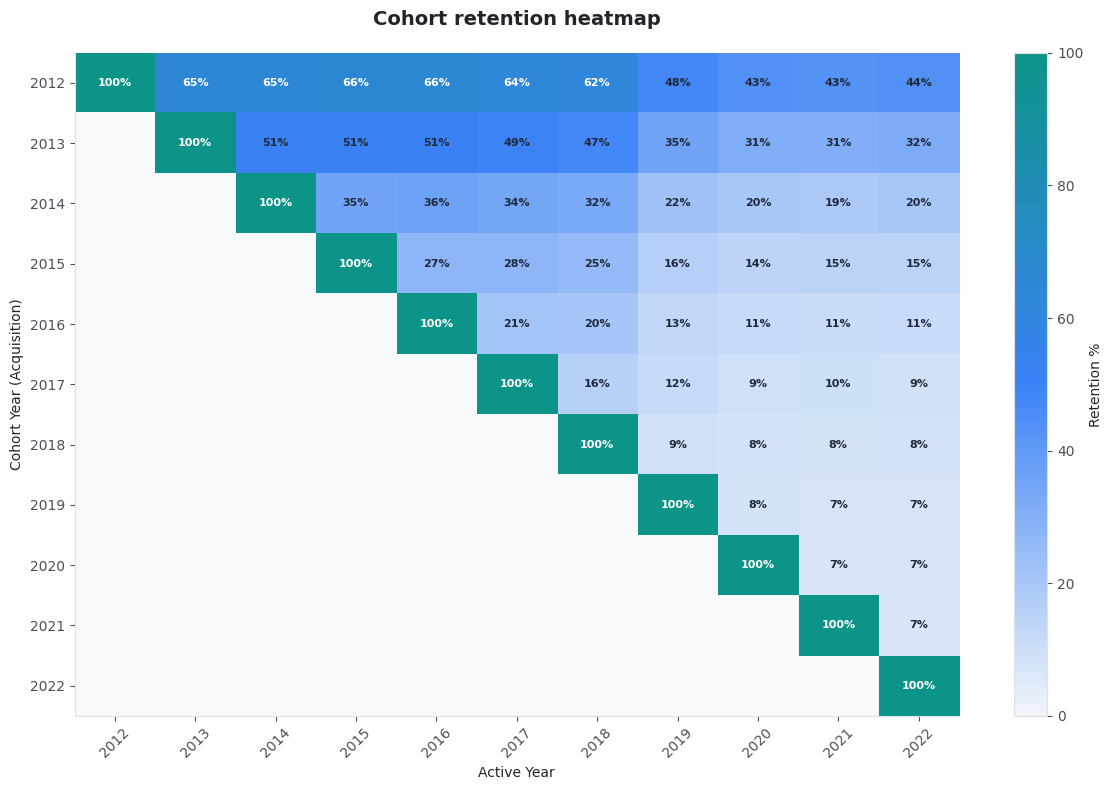

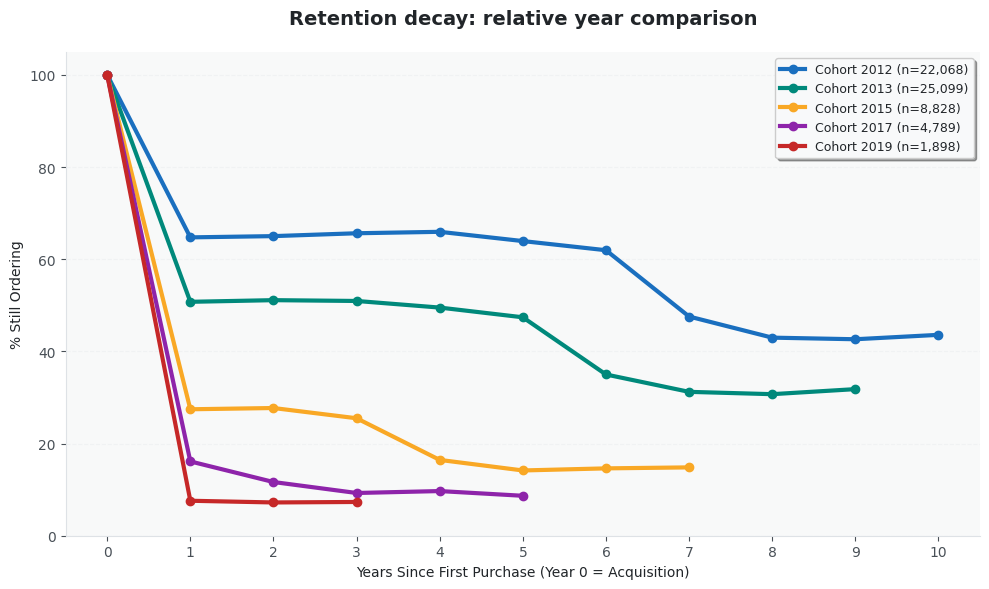

In [ ]:
first_order = orders.groupby('customer_id')['order_date'].min().reset_index()
first_order.columns = ['customer_id', 'first_order_date']
first_order['cohort_year'] = first_order['first_order_date'].dt.year

orders_with_cohort = orders.merge(first_order[['customer_id', 'cohort_year']], on='customer_id')

cohort_matrix = orders_with_cohort.groupby(['cohort_year', 'year'])['customer_id'].nunique().reset_index()

cohort_size = cohort_matrix[cohort_matrix['year'] == cohort_matrix['cohort_year']].set_index('cohort_year')['customer_id']

cohort_matrix['retention_pct'] = cohort_matrix.apply(
    lambda r: r['customer_id'] / cohort_size.get(r['cohort_year'], 1) * 100, axis=1)

pivot_cohort = cohort_matrix.pivot(index='cohort_year', columns='year', values='retention_pct')

plt.figure(figsize=(12, 8))
from matplotlib.colors import LinearSegmentedColormap
cmap_ret = LinearSegmentedColormap.from_list('ret', ['#F1F5F9', '#3B82F6', '#0D9488'])

im = plt.imshow(pivot_cohort.values, cmap=cmap_ret, aspect='auto', vmin=0, vmax=100)

plt.xticks(range(len(pivot_cohort.columns)), pivot_cohort.columns.astype(int), rotation=45)
plt.yticks(range(len(pivot_cohort.index)), pivot_cohort.index.astype(int))

plt.title('Cohort retention heatmap', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Active Year'); plt.ylabel('Cohort Year (Acquisition)')

for i in range(len(pivot_cohort.index)):
    for j in range(len(pivot_cohort.columns)):
        val = pivot_cohort.iloc[i, j]
        if not np.isnan(val):
            plt.text(j, i, f'{val:.0f}%', ha='center', va='center',
                     fontsize=8, fontweight='bold', color='white' if val > 55 else '#1E293B')

plt.colorbar(im, label='Retention %')
plt.tight_layout()
plt.show()

# Relative Year Line Chart (Fair Comparison)
plt.figure(figsize=(10, 6))
ax = plt.gca()

key_cohorts = [2012, 2013, 2015, 2017, 2019]

colors_key = ['#1A6FBF', '#00897B', '#F9A825', '#8E24AA', '#C62828']

for cohort, color in zip(key_cohorts, colors_key):
    d = cohort_matrix[cohort_matrix['cohort_year'] == cohort].copy()
    d['rel_year'] = d['year'] - cohort
    n = cohort_size.get(cohort, 0)

    ax.plot(d['rel_year'], d['retention_pct'], marker='o', lw=3, color=color,
            label=f'Cohort {cohort} (n={n:,})', ms=6)

ax.set_title('Retention decay: relative year comparison',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Years Since First Purchase (Year 0 = Acquisition)')
ax.set_ylabel('% Still Ordering')
ax.set_xticks(range(0, 11))
ax.set_ylim(0, 105)
ax.set_facecolor('#F8F9F9')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(fontsize=9, loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

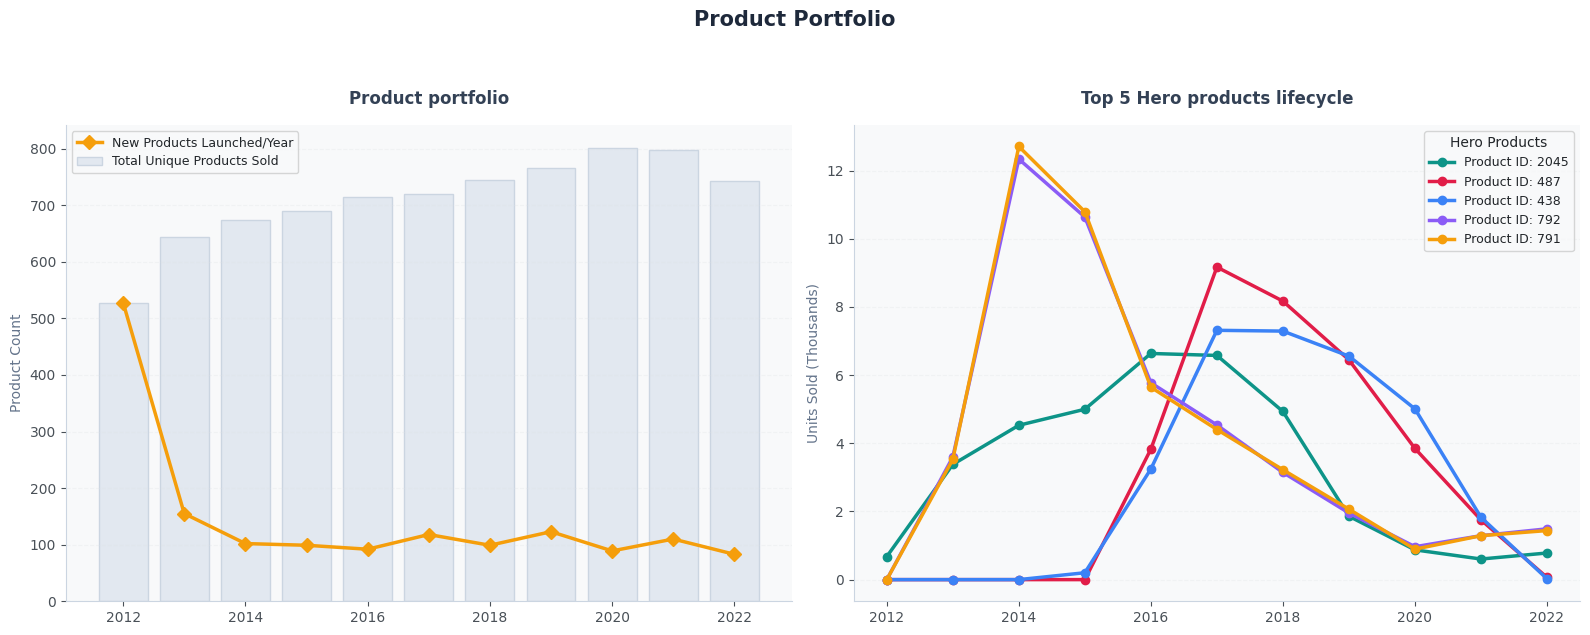

In [ ]:
# ── 3-E: Product Portfolio & Flagship Lifecycle ──────────────────────────────
# Tính toán danh mục
catalog_yr = oi_prod.groupby('year')['product_id'].nunique().reset_index(name='unique_products_sold')
first_sold = oi_prod.groupby('product_id')['year'].min().reset_index()
new_products_yr = first_sold.groupby('year')['product_id'].nunique().reset_index(name='new_products_launched')

product_trends = catalog_yr.merge(new_products_yr, on='year', how='left').fillna(0)

# Tìm Top 5 Hero Products theo volume
peak_sales = oi_prod[oi_prod['year'].isin([2016, 2017])].groupby('product_id').agg(qty=('quantity', 'sum')).reset_index()
top5_products = peak_sales.sort_values('qty', ascending=False).head(5)['product_id'].tolist()

top_prod_sales = oi_prod[oi_prod['product_id'].isin(top5_products)].groupby(['year', 'product_id'])['quantity'].sum().unstack(fill_value=0)

# Vẽ biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Product Portfolio', fontsize=15, fontweight='bold', y=1.05, color='#1E293B')
fig.patch.set_facecolor('white')

# --- Chart 1: Catalog Size & Innovation ---
ax1.bar(product_trends['year'], product_trends['unique_products_sold'], color='#E2E8F0', edgecolor='#CBD5E1', label='Total Unique Products Sold')
ax1.plot(product_trends['year'], product_trends['new_products_launched'], color='#F59E0B', marker='D', lw=2.5, ms=7, label='New Products Launched/Year')

ax1.set_title('Product portfolio', fontsize=12, fontweight='bold', pad=15, color='#334155')
ax1.set_ylabel('Product Count', color='#64748B')
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.legend(loc='upper left', fontsize=9, frameon=True)

# --- Chart 2: Top 5 Flagships Decline ---
colors = ['#0D9488', '#E11D48', '#3B82F6', '#8B5CF6', '#F59E0B']
for idx, prod in enumerate(top5_products):
    ax2.plot(top_prod_sales.index, top_prod_sales[prod]/1000, color=colors[idx], marker='o', lw=2.5, ms=6, label=f'Product ID: {prod}')

ax2.set_title('Top 5 Hero products lifecycle', fontsize=12, fontweight='bold', pad=15, color='#334155')
ax2.set_ylabel('Units Sold (Thousands)', color='#64748B')
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.legend(loc='upper right', fontsize=9, title='Hero Products', frameon=True)

# Thẩm mỹ viền
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CBD5E1')
    ax.spines['bottom'].set_color('#CBD5E1')

plt.tight_layout()
plt.show()


══════════════════════════════════════════════════════════════════════
  Phân tích Hàng Tồn Đọng (Zombie Products)
  Không phát sinh đơn > 180 ngày nhưng còn tồn kho
══════════════════════════════════════════════════════════════════════


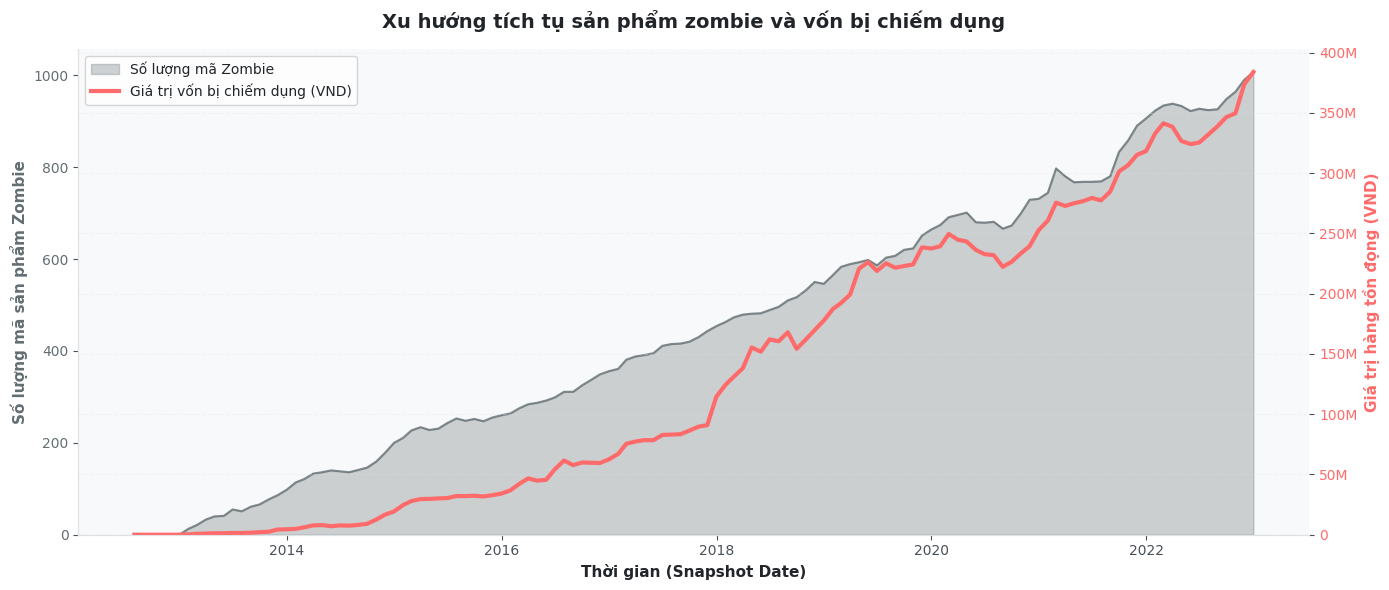

In [ ]:
# 1. Lấy thông tin ngày order cuối cùng
oi_orders = order_items.merge(orders[['order_id', 'order_date']], on='order_id')
prod_orders = oi_orders[['product_id', 'order_date']].drop_duplicates()
prod_orders['order_date'] = pd.to_datetime(prod_orders['order_date'])
prod_orders = prod_orders.sort_values('order_date')

# 2. XỬ LÝ BẢNG TỒN KHO: TẠO FULL GRID & FORWARD-FILL
inv_df = inventory[['snapshot_date', 'product_id', 'stock_on_hand']].copy()
inv_df['snapshot_date'] = pd.to_datetime(inv_df['snapshot_date'])

# Tạo khung thời gian đầy đủ cho mọi mã hàng
unique_dates = inv_df['snapshot_date'].drop_duplicates().sort_values()
unique_prods = inv_df['product_id'].unique()
idx = pd.MultiIndex.from_product([unique_dates, unique_prods], names=['snapshot_date', 'product_id'])
inv_full = pd.DataFrame(index=idx).reset_index()

# Merge với dữ liệu tồn kho thực tế và điền khuyết (Forward Fill)
inv_full = inv_full.merge(inv_df, on=['snapshot_date', 'product_id'], how='left')
inv_full = inv_full.sort_values(['product_id', 'snapshot_date'])
inv_full['stock_on_hand'] = inv_full.groupby('product_id')['stock_on_hand'].ffill()

# Bỏ đi các dòng rác trước khi sản phẩm được nhập kho lần đầu tiên
inv_full = inv_full.dropna(subset=['stock_on_hand'])
inv_full = inv_full.sort_values('snapshot_date')

# 3. Ghép ngày order gần nhất
zombie_df = pd.merge_asof(
    inv_full,
    prod_orders,
    left_on='snapshot_date',
    right_on='order_date',
    by='product_id',
    direction='backward'
)

# 4. Định nghĩa Zombie
# Tính khoảng thời gian từ đơn hàng cuối cùng
zombie_df['days_since_last_order'] = (zombie_df['snapshot_date'] - zombie_df['order_date']).dt.days
# Tìm "Ngày sinh" (First Stock Date) của từng sản phẩm trong kho
first_stock_dates = inventory.groupby('product_id')['snapshot_date'].min().reset_index()
first_stock_dates.rename(columns={'snapshot_date': 'first_stock_date'}, inplace=True)
first_stock_dates['first_stock_date'] = pd.to_datetime(first_stock_dates['first_stock_date'])
# Ghép "Ngày sinh" vào data tổng
zombie_df = zombie_df.merge(first_stock_dates, on='product_id', how='left')
zombie_df['days_since_first_stock'] = (zombie_df['snapshot_date'] - zombie_df['first_stock_date']).dt.days
# LOGIC ZOMBIE CHUẨN XÁC:
zombie_df['is_zombie'] = (zombie_df['stock_on_hand'] > 0) & (
    # Trường hợp 1: Đã từng bán được, nhưng 180 ngày qua không có đơn
    (zombie_df['days_since_last_order'] > 180) |
    # Trường hợp 2: Chưa từng có đơn (NaT) VÀ đã "nằm mốc mỏ" trong kho > 180 ngày kể từ lúc nhập
    (zombie_df['order_date'].isna() & (zombie_df['days_since_first_stock'] > 180))
)

# 5. Tính giá trị bị giam hãm
zombie_df = zombie_df.merge(products[['product_id', 'cogs']], on='product_id', how='left')

zombie_df['stock_value'] = zombie_df['stock_on_hand'] * zombie_df['cogs']
zombie_df['zombie_value'] = np.where(zombie_df['is_zombie'], zombie_df['stock_value'], 0)

# Tổng hợp dữ liệu theo tháng
trend_df = zombie_df.groupby('snapshot_date').agg(
    zombie_count=('is_zombie', 'sum'),
    total_zombie_value=('zombie_value', 'sum')
).reset_index()

# 6. Vẽ Biểu Đồ
section_title('Phân tích Hàng Tồn Đọng (Zombie Products)', 'Không phát sinh đơn > 180 ngày nhưng còn tồn kho')

fig, ax1 = plt.subplots(figsize=(14, 6))

# Area Chart (Số lượng)
ax1.fill_between(trend_df['snapshot_date'], trend_df['zombie_count'], color=C['grey'], alpha=0.3, label='Số lượng mã Zombie')
ax1.plot(trend_df['snapshot_date'], trend_df['zombie_count'], color=C['grey'], alpha=0.8, linewidth=1.5)
ax1.set_ylabel('Số lượng mã sản phẩm Zombie', color=C['grey'], fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=C['grey'])
ax1.set_xlabel('Thời gian (Snapshot Date)', fontsize=11, fontweight='bold')
ax1.set_ylim(bottom=0)

# Line Chart (Giá trị)
ax2 = ax1.twinx()
ax2.plot(trend_df['snapshot_date'], trend_df['total_zombie_value'], color=C['red'], linewidth=3, label='Giá trị vốn bị chiếm dụng (VND)')
ax2.set_ylabel('Giá trị hàng tồn đọng (VND)', color=C['red'], fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=C['red'])
ax2.set_ylim(bottom=0)

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_b))

plt.title('Xu hướng tích tụ sản phẩm zombie và vốn bị chiếm dụng', fontsize=14, pad=15, fontweight='bold')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, facecolor='white')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


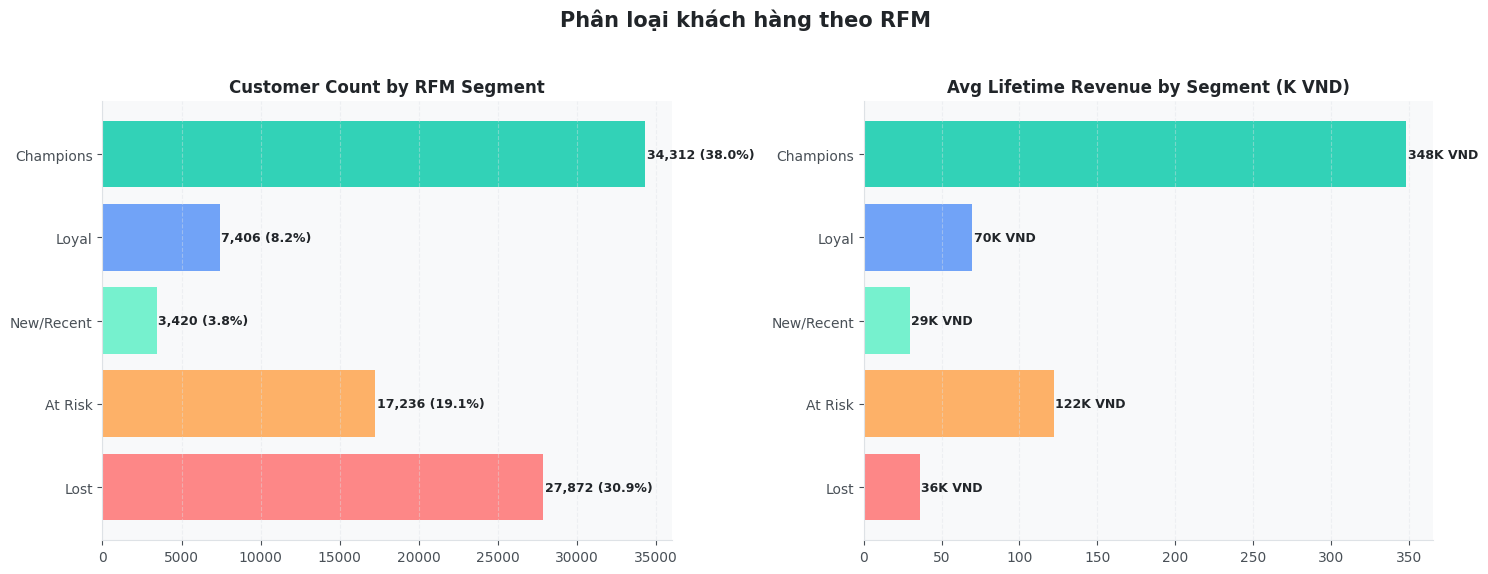

In [ ]:
# --- 1. Tính toán chỉ số RFM ---
snapshot = pd.Timestamp('2022-12-31')
# Sử dụng bảng orders_merged đã có từ các bước trước
rfm = orders_merged.groupby('customer_id').agg(
    recency  =('order_date', lambda x: (snapshot - x.max()).days),
    frequency=('order_id', 'count'),
    monetary =('payment_value', 'sum')
).reset_index()

# Scoring 1-4 bằng qcut
rfm['R'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)

# --- 2. Phân nhóm theo Logic Code 2 ---
def rfm_seg_logic2(row):
    r, f = row['R'], row['F']
    if r >= 3 and f >= 3: return 'Champions'
    if r >= 3 and f >= 2: return 'Loyal'
    if r >= 3 and f == 1: return 'New/Recent' # Đã đổi tên theo code 2
    if r == 2 and f >= 2: return 'At Risk'
    return 'Lost'

rfm['Segment'] = rfm.apply(rfm_seg_logic2, axis=1)

# Chuẩn bị dữ liệu vẽ biểu đồ
seg_counts  = rfm['Segment'].value_counts()
seg_revenue = rfm.groupby('Segment')['monetary'].mean()
seg_cmap    = {'Champions': C['teal'], 'Loyal': C['blue'], 'New/Recent': C['green'],
               'At Risk': C['orange'], 'Lost': C['red']}
seg_order   = ['Champions', 'Loyal', 'New/Recent', 'At Risk', 'Lost']

# --- 3. Trực quan hóa (Subplot 1x2) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Phân loại khách hàng theo RFM', fontsize=15, fontweight='bold', y=0.98)

# Chart 1: Customer Count
counts_vals = [seg_counts.get(s, 0) for s in seg_order]
bars1 = ax1.barh(seg_order, counts_vals, color=[seg_cmap[s] for s in seg_order], alpha=0.8)
for bar, v in zip(bars1, counts_vals):
    ax1.text(v + 100, bar.get_y() + bar.get_height()/2, f'{v:,} ({v/sum(counts_vals)*100:.1f}%)',
             va='center', fontsize=9, fontweight='bold')
ax1.set_title('Customer Count by RFM Segment', fontsize=12, fontweight='bold')
ax1.invert_yaxis() # Đảo ngược để Champions nằm trên cùng
ax1.grid(axis='x', linestyle='--', alpha=0.4)

# Chart 2: Avg Lifetime Revenue
rev_vals = [seg_revenue.get(s, 0)/1000 for s in seg_order]
bars2 = ax2.barh(seg_order, rev_vals, color=[seg_cmap[s] for s in seg_order], alpha=0.8)
for bar, v in zip(bars2, rev_vals):
    ax2.text(v + 1, bar.get_y() + bar.get_height()/2, f'{v:.0f}K VND', va='center', fontsize=9, fontweight='bold')
ax2.set_title('Avg Lifetime Revenue by Segment (K VND)', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

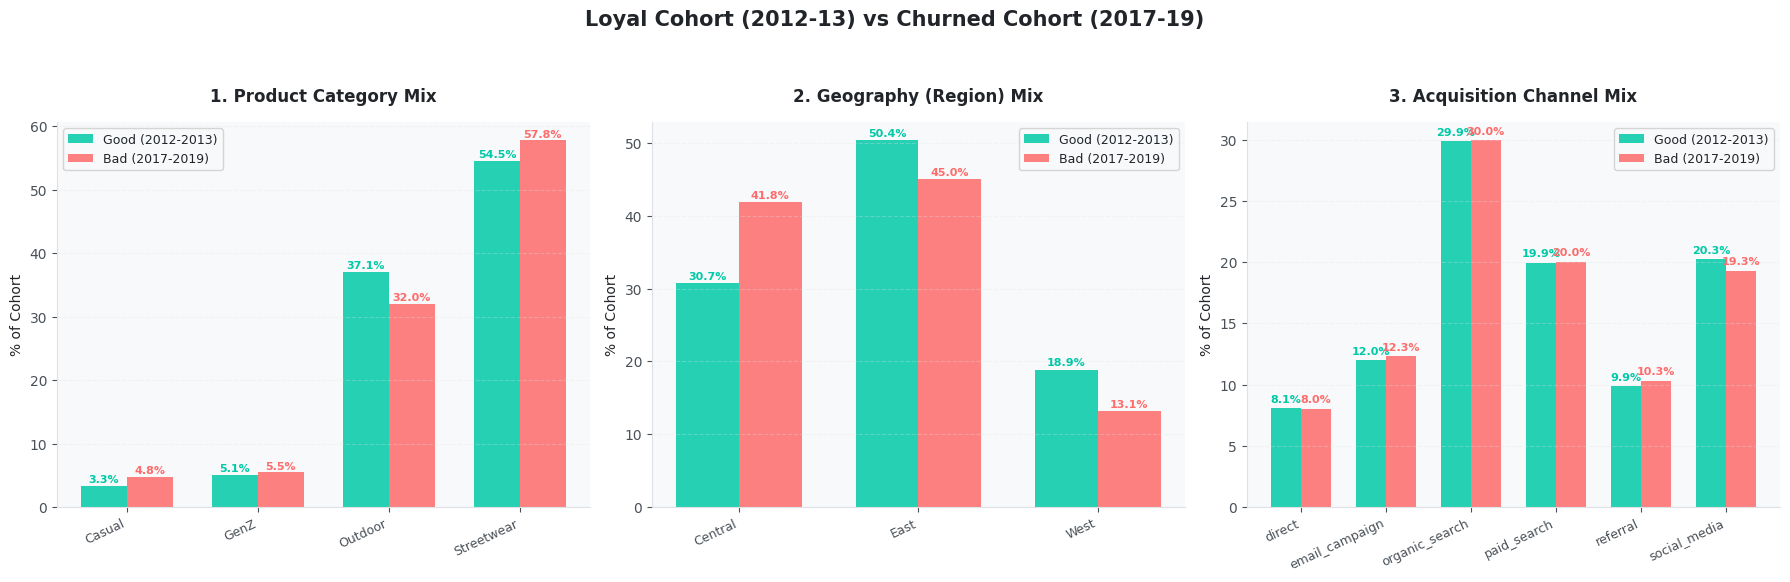

In [ ]:
# Phân nhóm khách hàng: Tốt (2012-2013) và Xấu (2017-2019) dựa vào năm mua đơn đầu tiên
first_order['cohort_group'] = np.where(first_order['cohort_year'].isin([2012, 2013]), 'Good (2012-2013)',
                              np.where(first_order['cohort_year'].isin([2017, 2018, 2019]), 'Bad (2017-2019)', 'Other'))

analysis_cohorts = first_order[first_order['cohort_group'] != 'Other']

cust_info = analysis_cohorts.merge(customers[['customer_id', 'acquisition_channel', 'zip']], on='customer_id')
cust_info = cust_info.merge(geography[['zip', 'region']], on='zip', how='left')

orders_with_cohort = orders.merge(analysis_cohorts[['customer_id', 'cohort_group']], on='customer_id')
full_data = oi_prod.merge(orders_with_cohort[['order_id', 'cohort_group']], on='order_id')

def get_mix(df, group_col, value_col):
    mix = df.groupby([group_col, value_col]).size().unstack(fill_value=0)
    return mix.div(mix.sum(axis=1), axis=0) * 100

category_mix = get_mix(full_data, 'cohort_group', 'category')
region_mix = get_mix(cust_info, 'cohort_group', 'region')
channel_mix = get_mix(cust_info, 'cohort_group', 'acquisition_channel')

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Loyal Cohort (2012-13) vs Churned Cohort (2017-19)', fontsize=15, fontweight='bold', y=1.05)
fig.patch.set_facecolor('white')

cohorts = ['Good (2012-2013)', 'Bad (2017-2019)']
colors = [C['teal'], C['red']]

def plot_grouped_bar(ax, mix_df, title, xlabel):
    x = np.arange(len(mix_df.columns))
    width = 0.35
    ax.bar(x - width/2, mix_df.loc[cohorts[0]], width, label=cohorts[0], color=colors[0], alpha=0.85)
    ax.bar(x + width/2, mix_df.loc[cohorts[1]], width, label=cohorts[1], color=colors[1], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(mix_df.columns, rotation=25, ha='right', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel('% of Cohort')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.legend(fontsize=9)

    # Hiển thị số liệu trên cột
    for i in x:
        val0 = mix_df.loc[cohorts[0]].iloc[i]
        val1 = mix_df.loc[cohorts[1]].iloc[i]
        ax.text(i - width/2, val0 + 0.5, f"{val0:.1f}%", ha='center', fontsize=8, color=colors[0], fontweight='bold')
        ax.text(i + width/2, val1 + 0.5, f"{val1:.1f}%", ha='center', fontsize=8, color=colors[1], fontweight='bold')

# Vẽ từng biểu đồ
plot_grouped_bar(axes[0], category_mix, '1. Product Category Mix', 'Category')
plot_grouped_bar(axes[1], region_mix, '2. Geography (Region) Mix', 'Region')
plot_grouped_bar(axes[2], channel_mix, '3. Acquisition Channel Mix', 'Channel')

plt.tight_layout()
plt.show()

## LAYER 4 - Review + return analysis

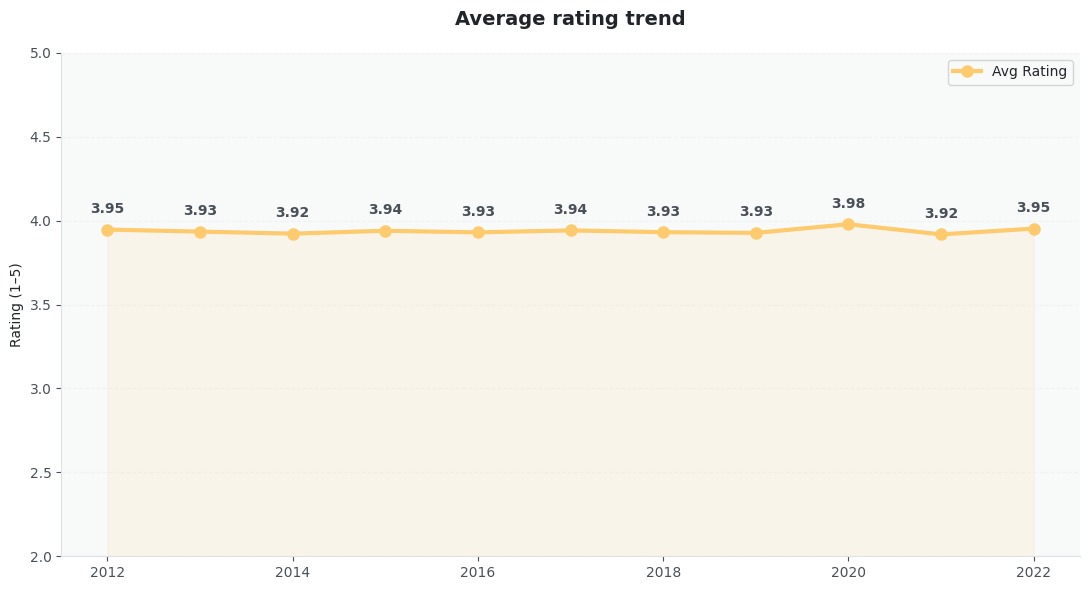

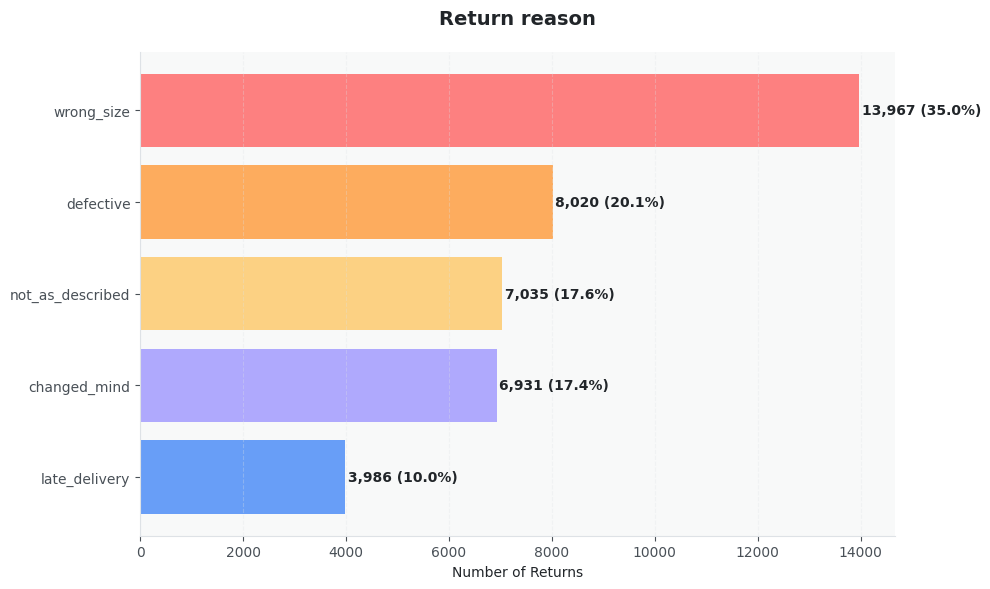

In [ ]:
annual_rev = reviews.groupby('year').agg(
    avg_rating=('rating','mean'),
    review_count=('review_id','count'),
    pct_5star=('rating', lambda x: (x==5).mean()*100),
    pct_1star=('rating', lambda x: (x==1).mean()*100),
).reset_index()

plt.figure(figsize=(11, 6))
ax = plt.gca()
plt.plot(annual_rev['year'], annual_rev['avg_rating'],
         marker='o', color=C['yellow'], lw=3, ms=8, label='Avg Rating')

# Đổ bóng nhẹ từ mốc 3.0 để chart trông đầy đặn hơn
plt.fill_between(annual_rev['year'], annual_rev['avg_rating'], 2.0,
                 alpha=0.1, color=C['yellow'])

for x, y in zip(annual_rev['year'], annual_rev['avg_rating']):
    plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0, 12),
                 ha='center', fontsize=10, fontweight='bold', color='#495057')

plt.title('Average rating trend', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Rating (1–5)')

# --- THIẾT LẬP SCALE THEO Ý BẠN ---
plt.ylim(2.0, 5.0)  # Max giữ 5, Min để 3 để chart "thoát" hơn
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5)) # Step 0.5 chuẩn bài

plt.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_facecolor('#F8F9F9')
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()


ret_reasons = returns['return_reason'].value_counts()
plt.figure(figsize=(10, 6))
ax = plt.gca()

reason_colors = [C['red'], C['orange'], C['yellow'], C['purple'], C['blue'], C['teal']]
bars = plt.barh(ret_reasons.index[::-1], ret_reasons.values[::-1],
                color=reason_colors[:len(ret_reasons)][::-1], alpha=0.85)
total_ret = ret_reasons.sum()
for i, (idx, v) in enumerate(ret_reasons[::-1].items()):
    plt.text(v + 50, i, f'{v:,} ({v/total_ret*100:.1f}%)', va='center', fontsize=10, fontweight='bold')
plt.title('Return reason', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Number of Returns')
plt.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_facecolor('#F8F9F9')

plt.tight_layout()
plt.show()

## LAYER 5 - conversion funnel: Web -> Order => Repeat

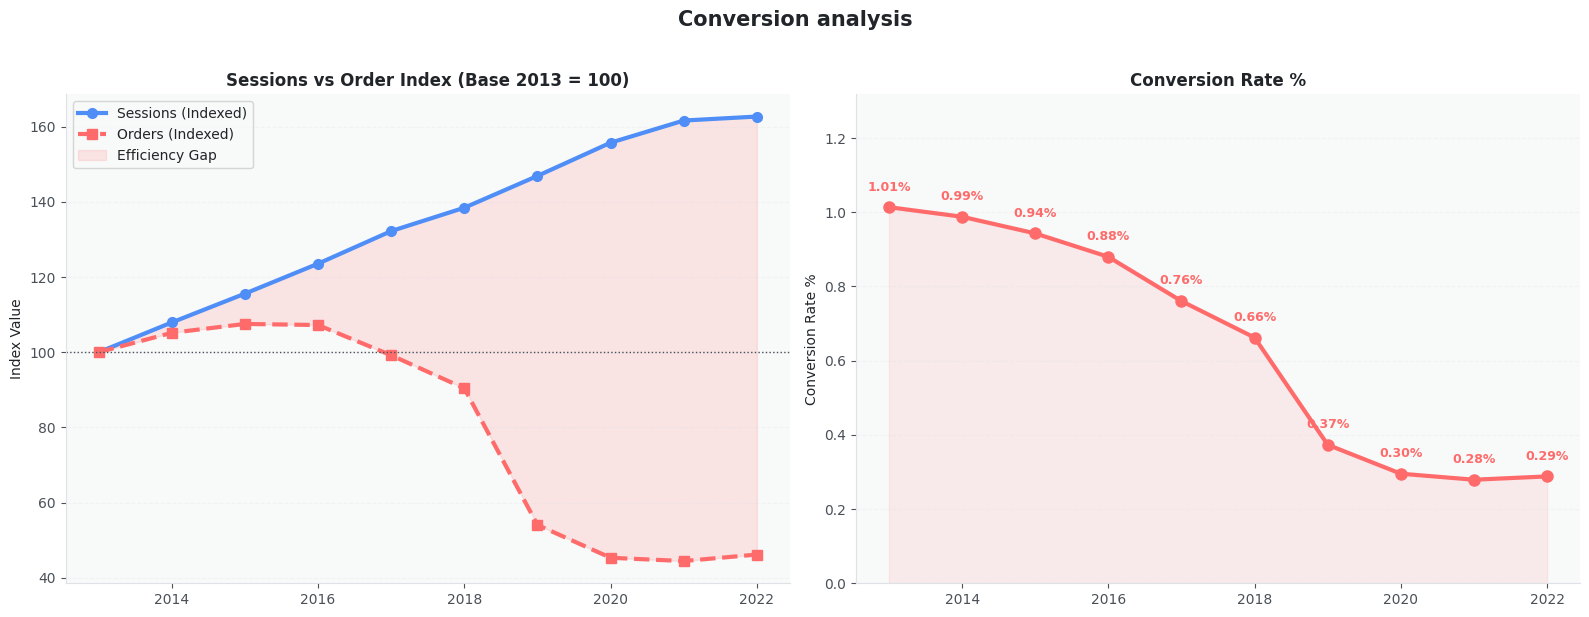

In [ ]:
wt_ann = web_traffic.groupby('year').agg(
    sessions        =('sessions','sum'),
    unique_visitors =('unique_visitors','sum'),
    avg_bounce      =('bounce_rate','mean'),
    avg_duration    =('avg_session_duration_sec','mean'),
    page_views      =('page_views','sum')
).reset_index()

completed = orders[orders['order_status'].isin(['delivered','shipped','paid','returned'])]
ord_yr = completed.groupby('year')['order_id'].nunique().reset_index(name='orders')

wt_ann = wt_ann.merge(ord_yr, on='year', how='left')
wt_ann['conv_rate'] = wt_ann['orders'] / wt_ann['sessions'] * 100

# Tạo chỉ số Index (Lấy năm đầu tiên làm gốc = 100)
base_yr = wt_ann[wt_ann['year']==wt_ann['year'].min()].iloc[0]
wt_ann['idx_sessions'] = wt_ann['sessions'] / base_yr['sessions'] * 100
wt_ann['idx_orders']   = wt_ann['orders']   / base_yr['orders']   * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Conversion analysis', fontsize=15, fontweight='bold', y=1.02)

yrs_wt = wt_ann['year'].values

# (Chart 1) Indexed Sessions vs Orders
ax1.plot(yrs_wt, wt_ann['idx_sessions'], marker='o', color=C['blue'],  lw=3, ms=7, label='Sessions (Indexed)')
ax1.plot(yrs_wt, wt_ann['idx_orders'],   marker='s', color=C['red'],   lw=3, ms=7, ls='--', label='Orders (Indexed)')
ax1.fill_between(yrs_wt, wt_ann['idx_sessions'], wt_ann['idx_orders'],
                 alpha=0.15, color=C['red'], label='Efficiency Gap')

ax1.axhline(100, color='#495057', lw=1, ls=':')
ax1.set_title(f'Sessions vs Order Index (Base {wt_ann["year"].min()} = 100)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Index Value'); ax1.legend(loc='upper left'); ax1.grid(axis='y', alpha=0.3)
ax1.set_facecolor('#F8F9F9')

# (Chart 2) Conversion Rate Trend
ax2.plot(yrs_wt, wt_ann['conv_rate'], marker='o', color=C['red'], lw=3, ms=8)
ax2.fill_between(yrs_wt, wt_ann['conv_rate'], alpha=0.1, color=C['red'])

# Data labels cho CR%
for x, y in zip(yrs_wt, wt_ann['conv_rate']):
    ax2.annotate(f'{y:.2f}%', (x, y), textcoords='offset points', xytext=(0, 12),
                 ha='center', fontsize=9, fontweight='bold', color=C['red'])

ax2.set_title('Conversion Rate %', fontsize=12, fontweight='bold')
ax2.set_ylabel('Conversion Rate %')
ax2.set_ylim(0, wt_ann['conv_rate'].max() * 1.3) # Tạo khoảng trống phía trên cho label
ax2.grid(axis='y', alpha=0.3)
ax2.set_facecolor('#F8F9F9')

plt.tight_layout()
plt.show()

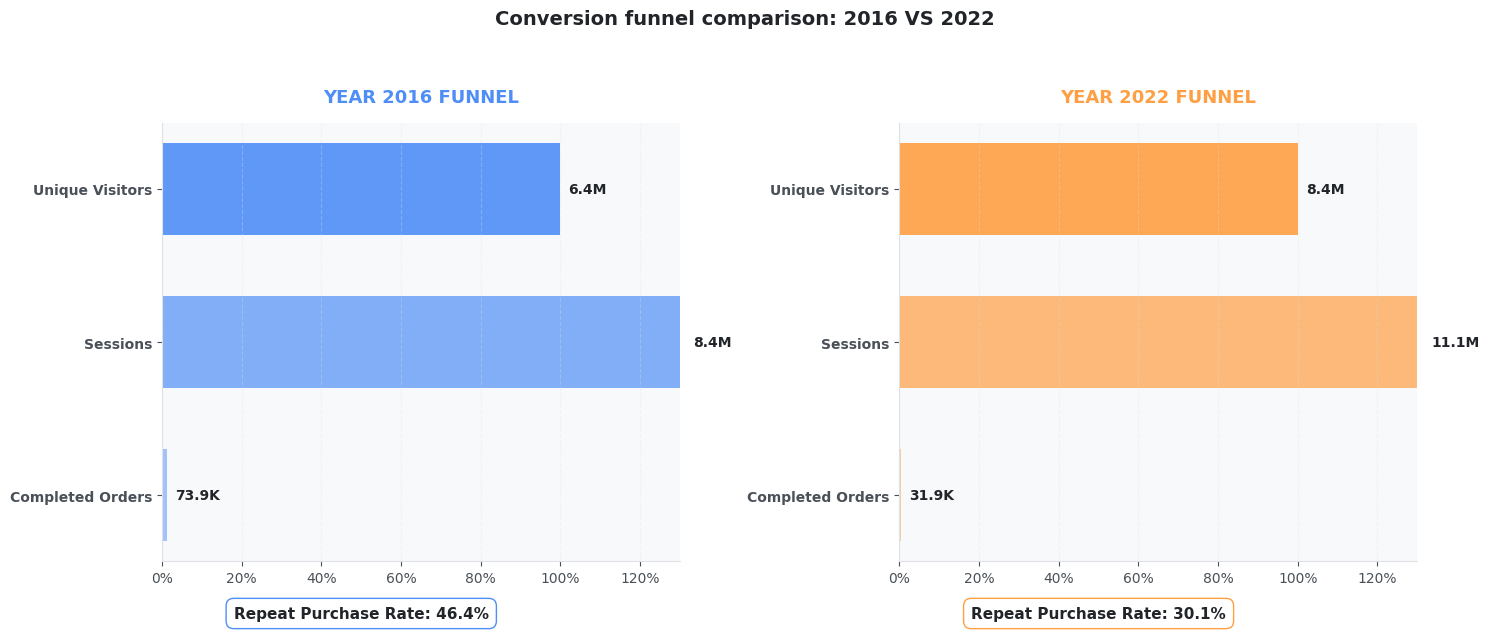

In [ ]:
funnel_yrs = [2016, 2022]
funnel_data = {}

cust_orders = orders.groupby(['year','customer_id']).size().reset_index(name='n_orders')
repeat_stats = cust_orders.groupby('year').apply(
    lambda df: (df['n_orders'] > 1).sum() / len(df) * 100
).reset_index(name='repeat_rate')

for yr in funnel_yrs:
    wt_row = wt_ann[wt_ann['year'] == yr]
    ord_row = ord_yr[ord_yr['year'] == yr]
    rep_row = repeat_stats[repeat_stats['year'] == yr]

    if len(wt_row) > 0:
        funnel_data[yr] = {
            'Unique Visitors': wt_row['unique_visitors'].values[0],
            'Sessions': wt_row['sessions'].values[0],
            'Completed Orders': ord_row['orders'].values[0] if len(ord_row) > 0 else 0,
            'Repeat Rate': rep_row['repeat_rate'].values[0] if len(rep_row) > 0 else 0
        }

stages = ['Unique Visitors', 'Sessions', 'Completed Orders']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Conversion funnel comparison: 2016 VS 2022',
             fontsize=14, fontweight='bold', color='#212529', y=1.05)

colors_f = {2016: C['blue'], 2022: C['orange']}

for ax, yr in zip(axes, funnel_yrs):
    if yr not in funnel_data: continue

    d = funnel_data[yr]
    vals = [d[s] for s in stages]
    widths = [v / vals[0] for v in vals]

    y_pos = np.arange(len(stages))

    for i, (stage, val, w) in enumerate(zip(stages, vals, widths)):
        idx = len(stages) - i - 1
        bar = ax.barh(idx, w, color=colors_f[yr], alpha=0.9 - i*0.2, height=0.6)

        label_val = f'{val/1e6:.1f}M' if val >= 1e6 else f'{val/1e3:.1f}K'
        ax.text(w + 0.02, idx, label_val, va='center', fontweight='bold', fontsize=10)

    ax.text(0.5, -0.8, f"Repeat Purchase Rate: {d['Repeat Rate']:.1f}%",
            ha='center', fontsize=11, fontweight='bold',
            bbox=dict(facecolor='none', edgecolor=colors_f[yr], boxstyle='round,pad=0.5'))

    ax.set_yticks(range(len(stages)))
    ax.set_yticklabels(stages[::-1], fontsize=10, fontweight='bold')
    ax.set_xlim(0, 1.3)
    ax.set_title(f'YEAR {yr} FUNNEL', fontsize=13, color=colors_f[yr], fontweight='bold', pad=15)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0%}'))
    ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


## LAYER 6 - Inventory

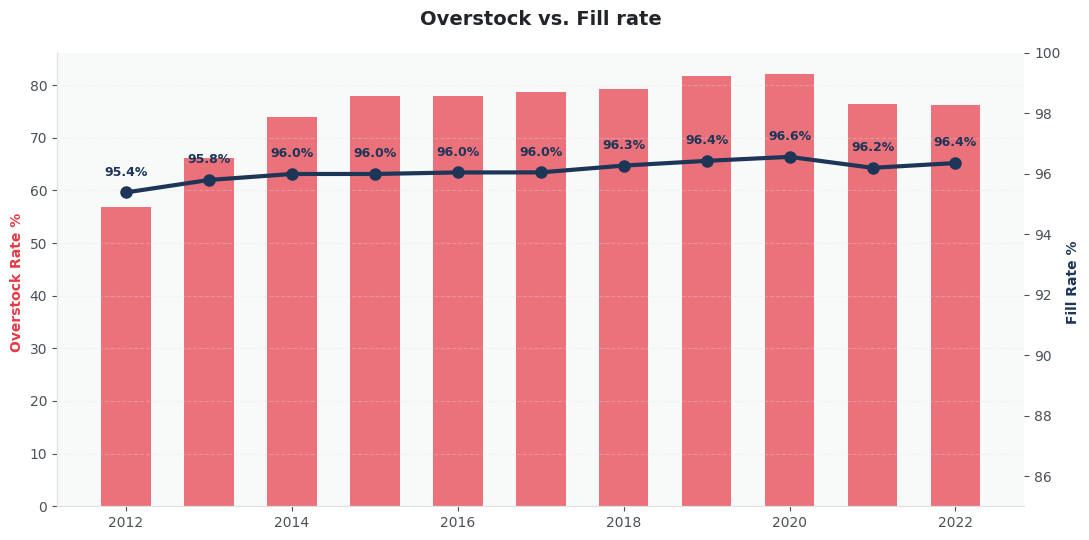

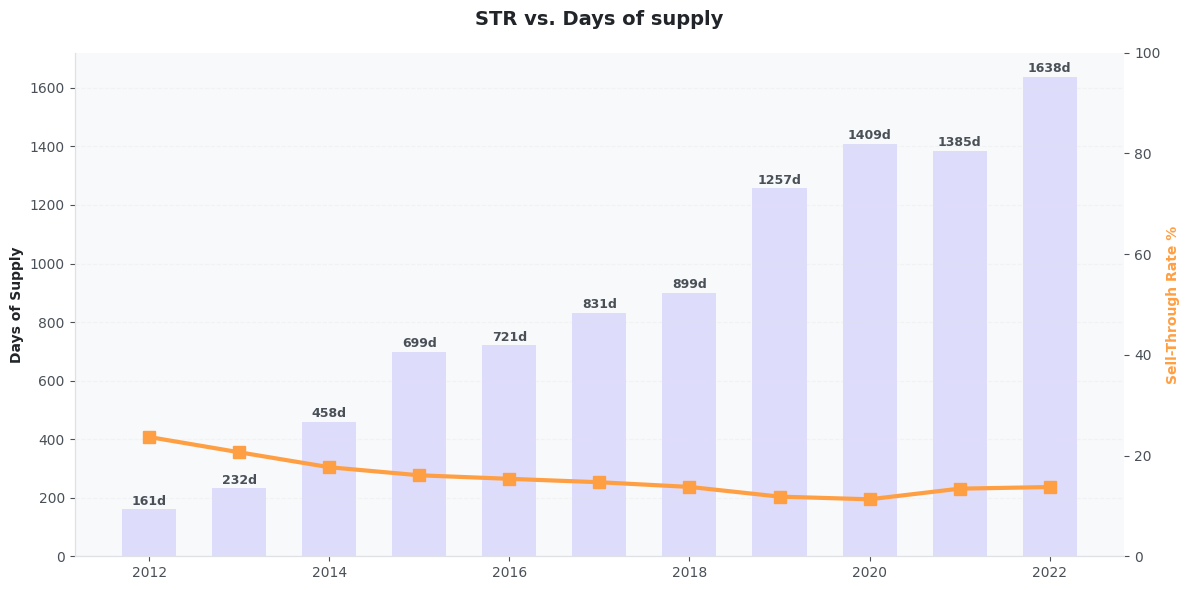

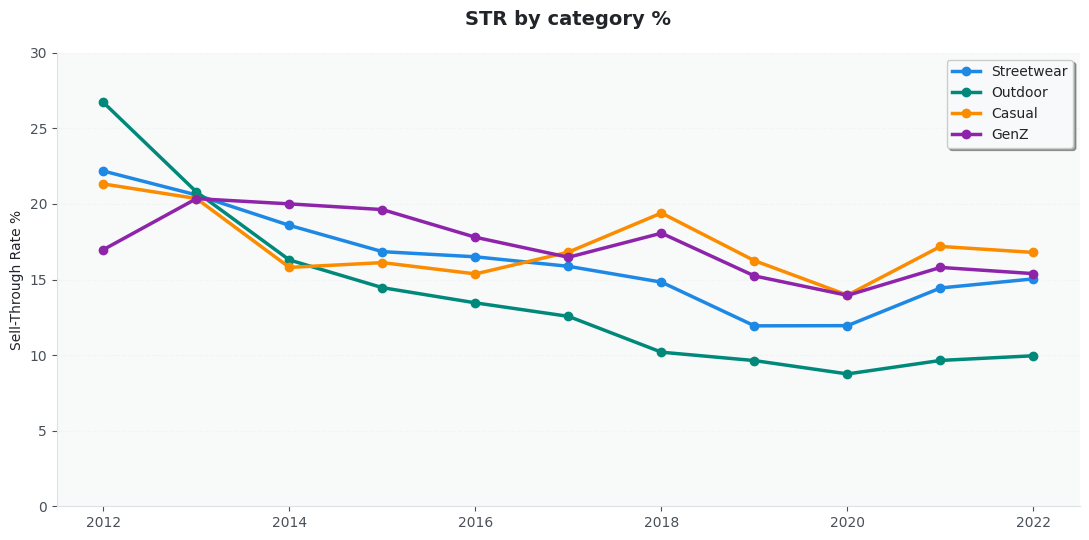

In [ ]:
# --- 1. Tính toán Inventory Metrics ---
inv_annual = inventory.groupby('year').agg(
    avg_overstock_rate=('overstock_flag','mean'),
    avg_stockout_rate=('stockout_flag','mean'),
    avg_fill_rate=('fill_rate','mean'),
    avg_sell_through=('sell_through_rate','mean'),
    avg_dos=('days_of_supply', 'mean') # Không lọc < 365 nữa, lấy full thực tế
).reset_index()

inv_cat = inventory.groupby(['year','category']).agg(
    avg_sell_through=('sell_through_rate','mean')
).reset_index()

yrs = inv_annual['year'].values

#(1)
plt.figure(figsize=(11, 5.5))
ax1 = plt.gca()

# Overstock Rate (Cột Đỏ - Cảnh báo)
ax1.bar(yrs, inv_annual['avg_overstock_rate']*100, color='#E63946', alpha=0.7, width=0.6, label='Overstock Rate %')
ax1.set_ylabel('Overstock Rate % ', color='#E63946', fontweight='bold')

# Fill Rate (Đường Xanh Navy - Tin cậy)
ax2 = ax1.twinx()
ax2.plot(yrs, inv_annual['avg_fill_rate']*100, color='#1D3557', marker='o', lw=3, ms=8, label='Fill Rate %')
ax2.set_ylabel('Fill Rate % ', color='#1D3557', fontweight='bold')

plt.title('Overstock vs. Fill rate', fontsize=14, fontweight='bold', pad=20)
ax2.set_ylim(85, 100) # Zoom sát để thấy biến động
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.set_facecolor('#F8F9F9')

# Annotate Fill Rate cho rõ số
for x, y in zip(yrs, inv_annual['avg_fill_rate']*100):
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", xytext=(0,12),
                 ha='center', fontsize=9, fontweight='bold', color='#1D3557')

plt.tight_layout()
plt.show()


#(2)
plt.figure(figsize=(12, 6))
ax1 = plt.gca()

# Days of Supply: Cột tím thể hiện thời gian hàng nằm chờ trong kho
ax1.bar(yrs, inv_annual['avg_dos'], color=C['purple'], alpha=0.3, width=0.6, label='Days of Supply (Days)')
ax1.set_ylabel('Days of Supply', fontweight='bold')

# Sell-Through Rate: Đường cam thể hiện tốc độ đẩy hàng
ax2 = ax1.twinx()
ax2.plot(yrs, inv_annual['avg_sell_through']*100, color=C['orange'], marker='s', lw=3, ms=8, label='Sell-Through Rate %')
ax2.set_ylabel('Sell-Through Rate %', color=C['orange'], fontweight='bold')

ax1.set_title('STR vs. Days of supply', fontsize=14, fontweight='bold', pad=20)
ax2.set_ylim(0, 100)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Label cho Days of Supply vì nó đang "uncapped" nên số sẽ rất to
for x, y in zip(yrs, inv_annual['avg_dos']):
    ax1.text(x, y + 5, f'{int(y)}d', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#495057')

plt.tight_layout()
plt.show()

#(3)
plt.figure(figsize=(11, 5.5))
ax = plt.gca()

cat_styles = [
    ('Streetwear', '#1E88E5'), # Blue
    ('Outdoor', '#00897B'),    # Teal
    ('Casual', '#FB8C00'),     # Orange
    ('GenZ', '#8E24AA')        # Purple
]

for cat, color in cat_styles:
    d = inv_cat[inv_cat['category'] == cat]
    if len(d) > 0:
        ax.plot(d['year'], d['avg_sell_through']*100, marker='o', lw=2.5, color=color, label=cat, ms=6)

ax.set_title('STR by category %', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Sell-Through Rate %')

ax.set_ylim(0, 30)

ax.grid(axis='y', linestyle='--', alpha=0.2)
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=10)
ax.set_facecolor('#F8F9F9')

plt.tight_layout()
plt.show()

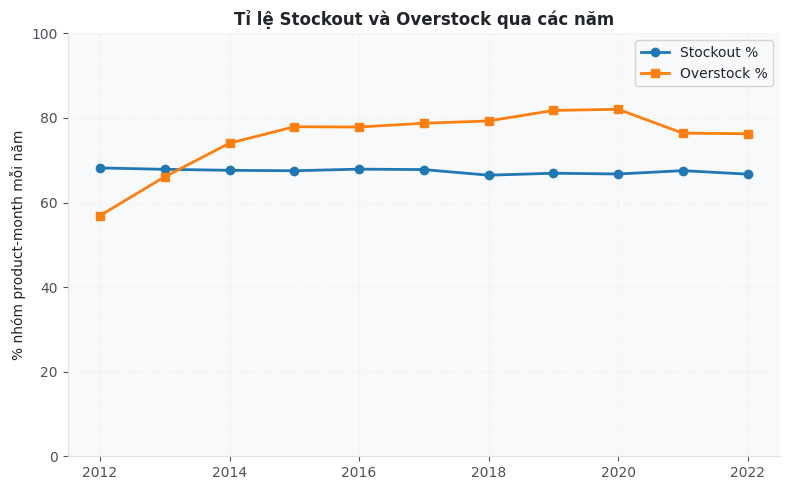

In [ ]:
# Stockout vs Overstock

fig, ax = plt.subplots(figsize=(8, 5))

inv_flags = inventory.groupby('year').agg(
    stockout_pct=('stockout_flag', 'mean'),
    overstock_pct=('overstock_flag', 'mean'),
).reset_index()

x = inv_flags['year']
ax.plot(x, inv_flags['stockout_pct']*100, marker='o',
        linewidth=2, label='Stockout %')
ax.plot(x, inv_flags['overstock_pct']*100, marker='s',
        linewidth=2, label='Overstock %')
ax.set_title("Tỉ lệ Stockout và Overstock qua các năm", fontweight='bold')
ax.set_ylabel("% nhóm product-month mỗi năm")
ax.set_xlabel(None)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

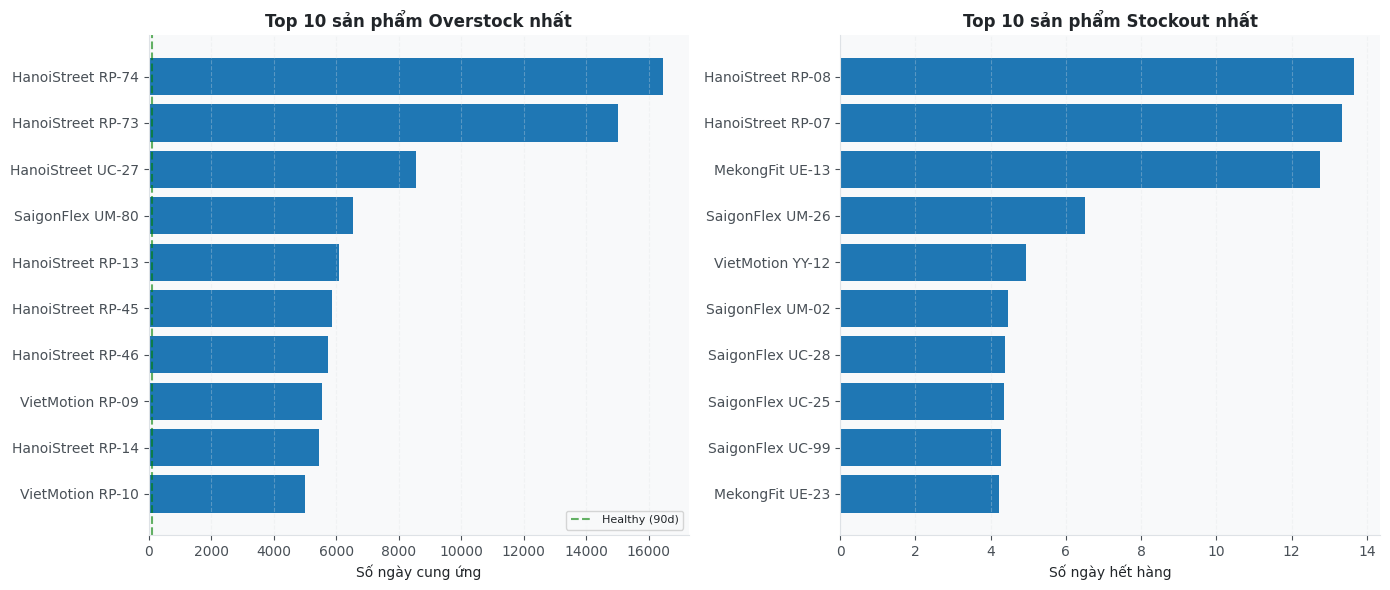

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 sản phẩm Overstock
top_over = inventory.groupby('product_name')['days_of_supply'].mean()\
                    .sort_values(ascending=False).head(10)
axes[0].barh(top_over.index[::-1], top_over.values[::-1])
axes[0].axvline(x=90, linestyle='--', color='green', alpha=0.6, label='Healthy (90d)')
axes[0].set_title("Top 10 sản phẩm Overstock nhất", fontweight='bold')
axes[0].set_xlabel("Số ngày cung ứng")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Top 10 sản phẩm Stockout
top_out = inventory.groupby('product_name')['stockout_days'].mean()\
                   .sort_values(ascending=False).head(10)
axes[1].barh(top_out.index[::-1], top_out.values[::-1])
axes[1].set_title("Top 10 sản phẩm Stockout nhất", fontweight='bold')
axes[1].set_xlabel("Số ngày hết hàng")
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

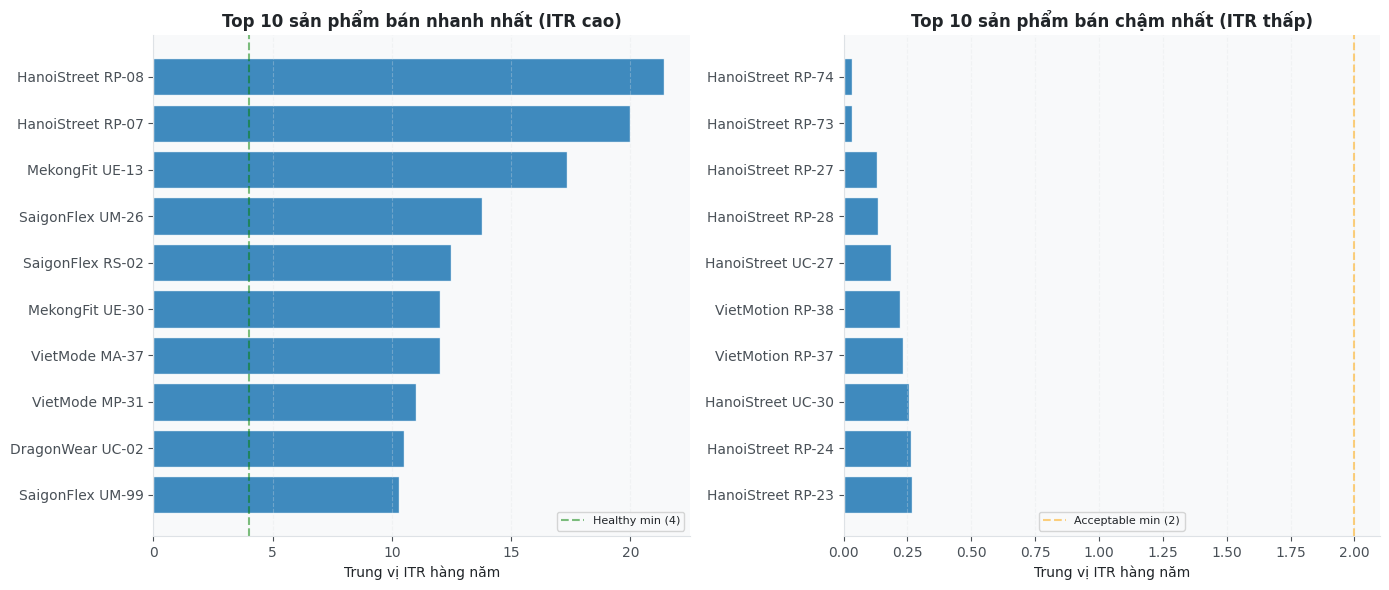

In [ ]:
inventory['ITR_annual'] = (inventory['units_sold'] / inventory['stock_on_hand'].replace(0, np.nan)) * 12

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
best  = inventory.groupby('product_name')['ITR_annual'].median().sort_values(ascending=False).head(10)
worst = inventory.groupby('product_name')['ITR_annual'].median().sort_values().head(10)

axes[0].barh(best.index[::-1], best.values[::-1], alpha=0.85, edgecolor='white')
axes[0].axvline(x=4, linestyle='--', color='green', alpha=0.5, label='Healthy min (4)')
axes[0].set_title("Top 10 sản phẩm bán nhanh nhất (ITR cao)", fontweight='bold')
axes[0].set_xlabel("Trung vị ITR hàng năm")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(worst.index[::-1], worst.values[::-1], alpha=0.85, edgecolor='white')
axes[1].axvline(x=2, linestyle='--', color='orange', alpha=0.5, label='Acceptable min (2)')
axes[1].set_title("Top 10 sản phẩm bán chậm nhất (ITR thấp)", fontweight='bold')
axes[1].set_xlabel("Trung vị ITR hàng năm")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [ ]:
# Nguyên nhân đến từ Reorder flag không được kích hoạt

print("\n% Reorder flag theo Category")
print((inventory.groupby('category')['reorder_flag'].mean()*100).round(2).to_string())


% Reorder flag theo Category
category
Casual        0.0
GenZ          0.0
Outdoor       0.0
Streetwear    0.0


## LAYER 7 - Web

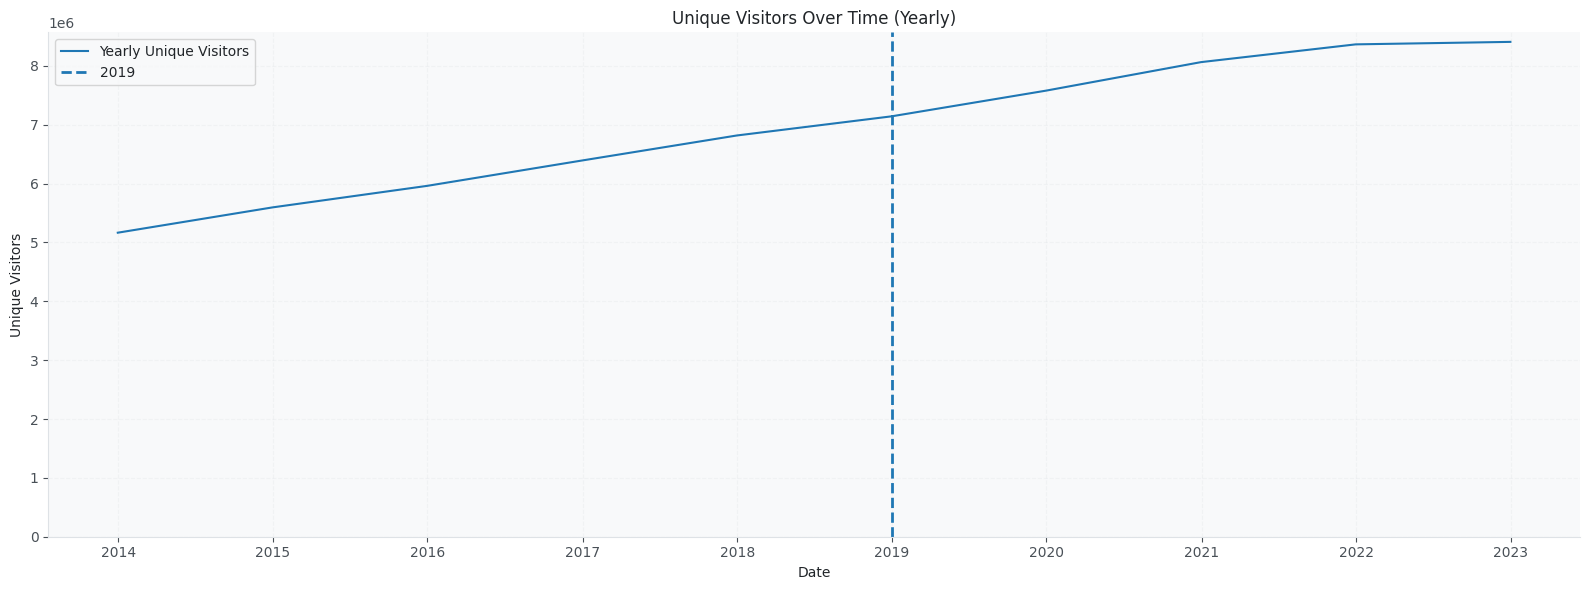

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Chuẩn bị dữ liệu
# =========================
uv = web_traffic.copy()
uv["date"] = pd.to_datetime(uv["date"])
uv = uv.sort_values("date")

# =========================
# 2) Aggregate theo tháng
# =========================
uv_yearly = (
    uv.resample("YE", on="date")["unique_visitors"] # Changed 'Y' to 'YE' to fix FutureWarning
    .sum()
    .reset_index()
)

# =========================
# 3) Vẽ chart
# =========================
plt.figure(figsize=(16, 6))
plt.plot(uv_yearly["date"], uv_yearly["unique_visitors"], label="Yearly Unique Visitors")
plt.axvline(pd.Timestamp("2019-01-01"), linestyle="--", linewidth=2, label="2019")

plt.title("Unique Visitors Over Time (Yearly)")
plt.xlabel("Date")
plt.ylabel("Unique Visitors")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

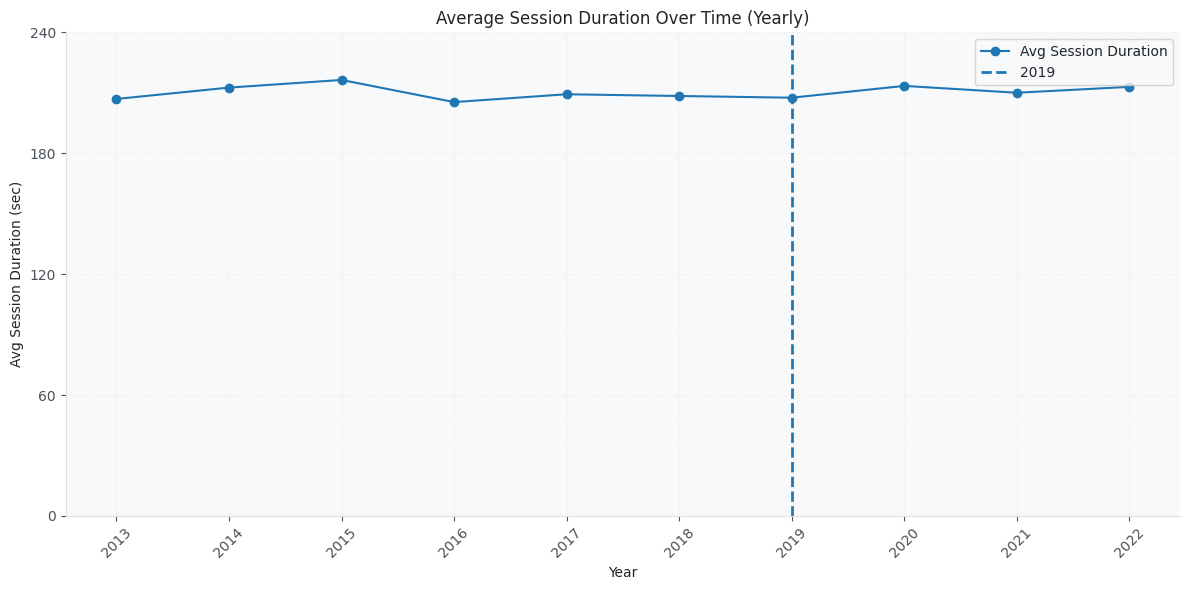

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Chuẩn bị dữ liệu
# =========================
asd = web_traffic.copy()
asd["date"] = pd.to_datetime(asd["date"])
asd = asd.sort_values("date")

# =========================
# 2) Aggregate theo năm
# =========================
asd_yearly = (
    asd.resample("YE", on="date")["avg_session_duration_sec"]
    .mean()
    .reset_index()
)
asd_yearly["Year"] = asd_yearly["date"].dt.year

# =========================
# 3) Vẽ chart
# =========================
plt.figure(figsize=(12, 6))
plt.plot(asd_yearly["Year"], asd_yearly["avg_session_duration_sec"], marker="o", label="Avg Session Duration")

# Vertical line tại năm 2019
plt.axvline(2019, linestyle="--", linewidth=2, label="2019")

plt.title("Average Session Duration Over Time (Yearly)")
plt.xlabel("Year")
plt.ylabel("Avg Session Duration (sec)")
plt.xticks(asd_yearly["Year"], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)

# Set y-axis ticks every 60 seconds
y_min, y_max = plt.ylim()
plt.yticks(range(int(y_min), int(y_max) + 60, 60))

plt.tight_layout()
plt.show()

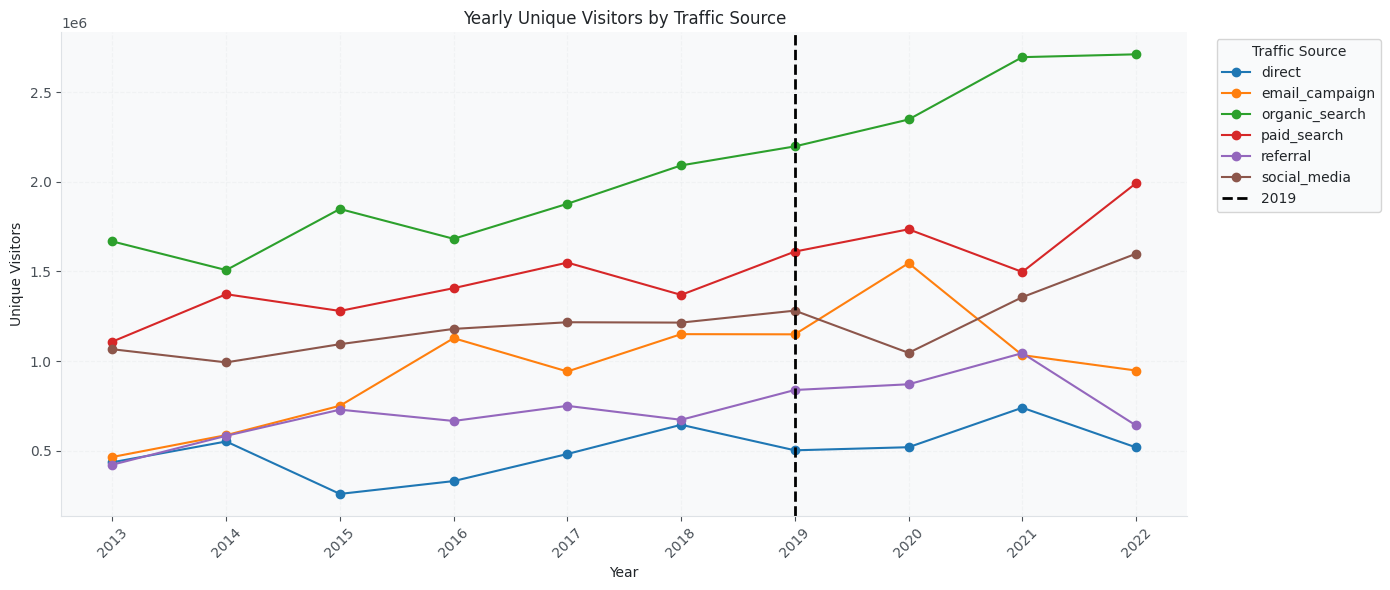

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Chuẩn bị dữ liệu
# =========================
uv = web_traffic.copy()
uv["date"] = pd.to_datetime(uv["date"])

# =========================
# 2) Aggregate theo năm và traffic source
# =========================
uv_yearly = (
    uv.groupby([pd.Grouper(key="date", freq="Y"), "traffic_source"])["unique_visitors"]
    .sum()
    .reset_index()
)

uv_yearly["Year"] = uv_yearly["date"].dt.year

# =========================
# 3) Vẽ chart
# =========================
plt.figure(figsize=(14, 6))

for source, data in uv_yearly.groupby("traffic_source"):
    plt.plot(data["Year"], data["unique_visitors"], marker="o", label=source)

# Vertical line tại năm 2019
plt.axvline(2019, linestyle="--", linewidth=2, color="black", label="2019")

plt.title("Yearly Unique Visitors by Traffic Source")
plt.xlabel("Year")
plt.ylabel("Unique Visitors")
plt.xticks(sorted(uv_yearly["Year"].unique()), rotation=45)
plt.legend(title="Traffic Source", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

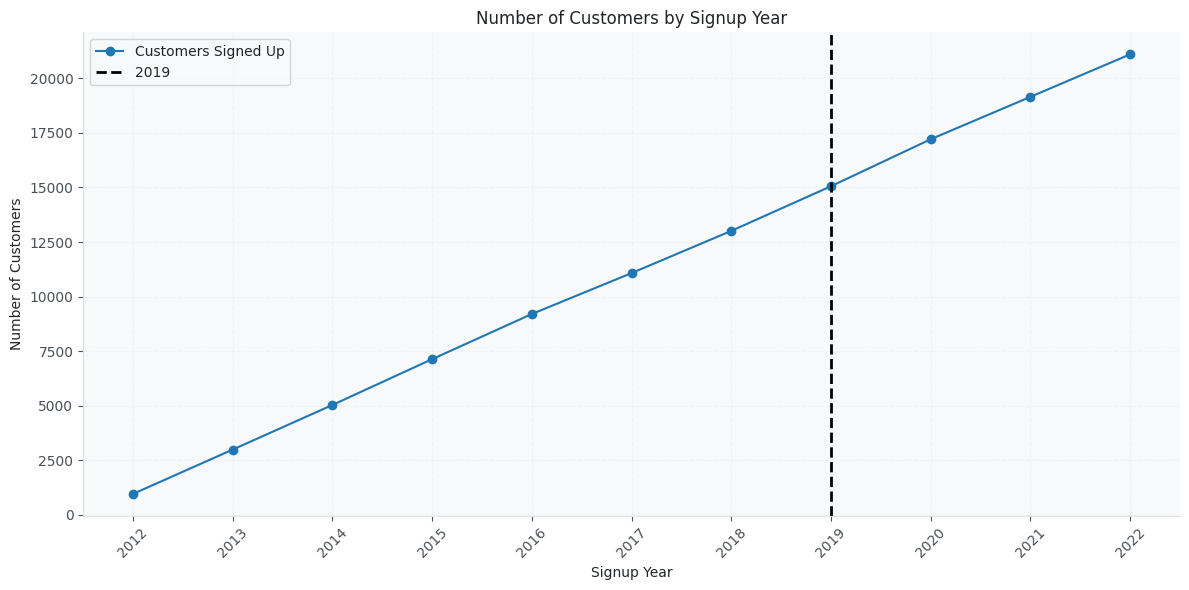

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Chuẩn bị dữ liệu
# =========================
signup = customers.copy()
signup["signup_date"] = pd.to_datetime(signup["signup_date"])
signup = signup.dropna(subset=["signup_date"])

signup["signup_year"] = signup["signup_date"].dt.year

# =========================
# 2) Đếm số lượng customer theo năm signup
# =========================
signup_yearly = (
    signup.groupby("signup_year")["customer_id"]
    .nunique()
    .reset_index(name="num_customers")
)

# =========================
# 3) Vẽ chart
# =========================
plt.figure(figsize=(12, 6))
plt.plot(signup_yearly["signup_year"], signup_yearly["num_customers"], marker="o", label="Customers Signed Up")
plt.axvline(2019, linestyle="--", linewidth=2, color="black", label="2019")

plt.title("Number of Customers by Signup Year")
plt.xlabel("Signup Year")
plt.ylabel("Number of Customers")
plt.xticks(signup_yearly["signup_year"], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

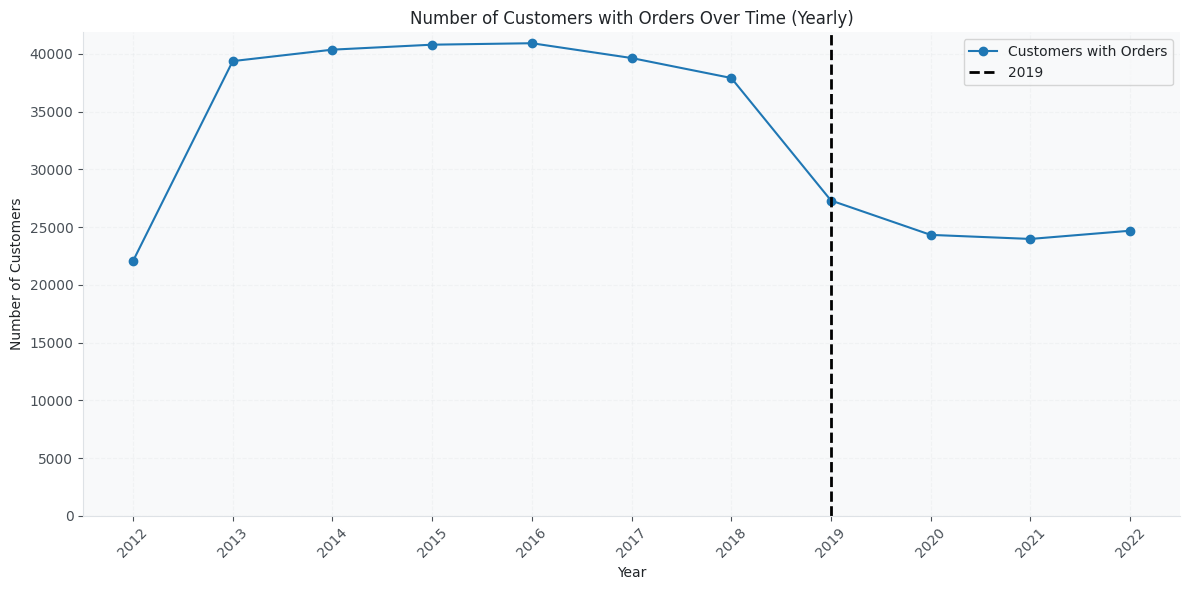

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Chuẩn bị dữ liệu
# =========================
orders = orders.copy()
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders = orders.dropna(subset=["order_date", "customer_id"])

orders["order_year"] = orders["order_date"].dt.year

# =========================
# 2) Đếm số khách hàng có order theo năm
# =========================
customers_yearly = (
    orders.groupby("order_year")["customer_id"]
    .nunique()
    .reset_index(name="num_customers_with_orders")
)

# =========================
# 3) Vẽ chart
# =========================
plt.figure(figsize=(12, 6))
plt.plot(
    customers_yearly["order_year"],
    customers_yearly["num_customers_with_orders"],
    marker="o",
    label="Customers with Orders"
)

plt.axvline(2019, linestyle="--", linewidth=2, color="black", label="2019")

plt.title("Number of Customers with Orders Over Time (Yearly)")
plt.xlabel("Year")
plt.ylabel("Number of Customers")
plt.xticks(customers_yearly["order_year"], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

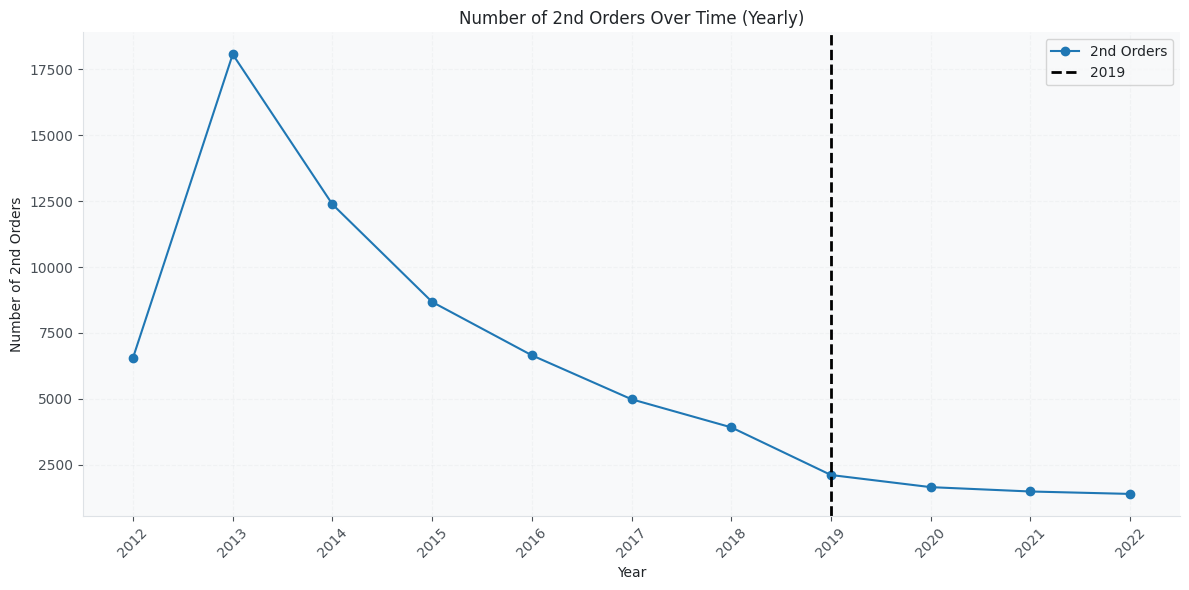

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Chuẩn bị dữ liệu
# =========================
orders = orders.copy()
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders = orders.dropna(subset=["order_date", "customer_id"])
orders = orders.sort_values(["customer_id", "order_date", "order_id"])

# Nếu chỉ muốn tính đơn hoàn tất thì bật dòng này
# orders = orders[orders["order_status"] == "delivered"].copy()

# =========================
# 2) Đánh số thứ tự order của từng customer
# =========================
orders["order_rank"] = orders.groupby("customer_id").cumcount() + 1

# =========================
# 3) Lấy các order lần thứ 2
# =========================
second_orders = orders[orders["order_rank"] == 2].copy()

# =========================
# 4) Đếm số order thứ 2 theo năm
# =========================
second_orders_yearly = (
    second_orders.groupby(second_orders["order_date"].dt.year)
    .size()
    .reset_index(name="num_second_orders")
)

second_orders_yearly.columns = ["Year", "num_second_orders"]

# =========================
# 5) Vẽ chart
# =========================
plt.figure(figsize=(12, 6))
plt.plot(
    second_orders_yearly["Year"],
    second_orders_yearly["num_second_orders"],
    marker="o",
    label="2nd Orders"
)

plt.axvline(2019, linestyle="--", linewidth=2, color="black", label="2019")

plt.title("Number of 2nd Orders Over Time (Yearly)")
plt.xlabel("Year")
plt.ylabel("Number of 2nd Orders")
plt.xticks(second_orders_yearly["Year"], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()